# 01 · Data Research: BTC/USDT and ETH/USDT

**Goal:** understand the data-generating process of BTC and ETH *before* building any strategy.

Questions this notebook answers:
1. What data do we have, and can we trust it?
2. What are the statistical properties of returns (distribution, tails, dependence)?
3. How does volatility behave, and is it predictable?
4. Are there time-of-day / day-of-week effects, and are they stable?
5. What regimes and structural changes exist?
6. What do the volume / trade-count / taker-flow variables tell us?
7. How are BTC and ETH related, and is that relationship stable?
8. Which variables carry information about *future* returns or volatility, and does it survive robustness checks?

**Rules followed throughout**
- Sections 1–2 (inventory, data quality) use the full 2021–2025 data, since checking quality doesn't bias a strategy.
- Everything from Section 3 onwards uses **only the train split (2021–2023)**. Validation (2024) and test (2025) stay untouched so they remain honest out-of-sample checks.
- Every predictor is built from information available at the close of the bar it belongs to (no look-ahead).

## 0. Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, coint
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 160)

In [2]:
ROOT = Path.cwd().parent            # notebook lives in notebooks/
RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

ASSETS = ["BTCUSDT", "ETHUSDT"]
COLORS = {"BTCUSDT": "#F7931A", "ETHUSDT": "#627EEA"}
TRAIN_END = "2023-12-31"


def savefig(fig, name):
    # Save a figure for the research report
    fig.savefig(FIG / f"{name}.png", dpi=120, bbox_inches="tight")

## 1. Data inventory

What files exist, how many rows, and what period they cover.

In [3]:
rows = []
for path in sorted(RAW.glob("*.csv")) + sorted(PROC.glob("*/*.csv")):
    first_col = pd.read_csv(path, usecols=[0]).iloc[:, 0]
    rows.append({
        "file": str(path.relative_to(ROOT)),
        "rows": len(first_col),
        "first": first_col.iloc[0],
        "last": first_col.iloc[-1],
        "MB": round(path.stat().st_size / 1e6, 1),
    })
pd.DataFrame(rows)

,file,rows,first,last,MB
0,data/raw/BTCUSDT_1d.csv,1826,2021-01-01 00:00:00,2025-12-31 00:00:00,0.3000
1,data/raw/BTCUSDT_1h.csv,43810,2021-01-01 00:00:00,2025-12-31 23:00:00,7.5000
2,data/raw/ETHUSDT_1d.csv,1826,2021-01-01 00:00:00,2025-12-31 00:00:00,0.3000
3,data/raw/ETHUSDT_1h.csv,43810,2021-01-01 00:00:00,2025-12-31 23:00:00,7.4000
4,data/processed/1d/BTCUSDT_full.csv,1826,2021-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,0.3000
5,data/processed/1d/BTCUSDT_test.csv,365,2025-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,0.1000
6,data/processed/1d/BTCUSDT_train.csv,1095,2021-01-01 00:00:00+00:00,2023-12-31 00:00:00+00:00,0.2000
7,data/processed/1d/BTCUSDT_val.csv,366,2024-01-01 00:00:00+00:00,2024-12-31 00:00:00+00:00,0.1000
8,data/processed/1d/ETHUSDT_full.csv,1826,2021-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,0.3000
9,data/processed/1d/ETHUSDT_test.csv,365,2025-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,0.1000


**Raw vs derived**
- `data/raw/*_1h.csv`, `*_1d.csv`: Binance spot klines downloaded from the public REST API (`/api/v3/klines`), untouched.
- `data/processed/1h`: raw hourly data after cleaning (`src/data/preprocess.py`): types set, `close_time` dropped, 14 missing hours filled with flat candles (`is_filled = True`), returns added.
- `data/processed/4h`, `1d`: built by aggregating the cleaned hourly data (not downloaded).

Let's look at the raw variables.

In [4]:
raw = {s: pd.read_csv(RAW / f"{s}_1h.csv", parse_dates=["timestamp", "close_time"]) for s in ASSETS}
raw["BTCUSDT"].head(3)

,timestamp,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base,taker_buy_quote
0,2021-01-01 00:00:00,28923.6300,29031.3400,28690.1700,28995.1300,2311.8114,2021-01-01 00:59:59,66768830.3401,58389,1215.3592,35103542.7829
1,2021-01-01 01:00:00,28995.1300,29470.0000,28960.3500,29409.9900,5403.0685,2021-01-01 01:59:59,158357816.8181,103896,3160.0417,92613991.9356
2,2021-01-01 02:00:00,29410.0000,29465.2600,29120.0300,29194.6500,2384.2316,2021-01-01 02:59:59,69842653.6734,57646,1203.4335,35252749.9083


| Column | Meaning |
|---|---|
| `timestamp` | Candle **open** time, UTC |
| `open, high, low, close` | Prices in USDT |
| `volume` | Traded quantity in the base asset (BTC or ETH) |
| `close_time` | Candle close time (open + 59:59.999) |
| `quote_volume` | Traded value in USDT |
| `trades` | Number of trades in the hour |
| `taker_buy_base` | Base volume where the **aggressor was a buyer** (market buy orders) |
| `taker_buy_quote` | Same, in USDT |

**Timestamp convention check:** a candle's close/high/low/volume are only known at `close_time`, i.e. one hour *after* `timestamp`.

In [5]:
for s, df in raw.items():
    print(s, (df["close_time"] - df["timestamp"]).value_counts().to_dict())

BTCUSDT {Timedelta('0 days 00:59:59'): 43806, Timedelta('0 days 00:40:54'): 1, Timedelta('0 days 00:00:58'): 1, Timedelta('0 days 00:59:54'): 1, Timedelta('0 days 00:39:41'): 1}
ETHUSDT {Timedelta('0 days 00:59:59'): 43806, Timedelta('0 days 00:40:55'): 1, Timedelta('0 days 00:00:59'): 1, Timedelta('0 days 00:59:56'): 1, Timedelta('0 days 00:39:43'): 1}


4 candles per asset close **before** :59:59. Which ones, and what's inside them?

In [6]:
short = raw["BTCUSDT"]["close_time"] - raw["BTCUSDT"]["timestamp"] != pd.Timedelta("59min 59s")
raw["BTCUSDT"].loc[short, ["timestamp", "close_time", "volume", "trades"]]

,timestamp,close_time,volume,trades
987,2021-02-11 03:00:00,2021-02-11 03:40:54,0.0000,0
2736,2021-04-25 04:00:00,2021-04-25 04:00:58,5.8870,224
8559,2021-12-24 04:00:00,2021-12-24 04:59:54,560.6232,22381
19487,2023-03-24 12:00:00,2023-03-24 12:39:41,0.0000,0


**Finding: 3 "hidden" outage bars.** The same 4 bars are short in both assets.
- 2021-02-11 03:00 and 2023-03-24 12:00 contain **zero volume and zero trades**. The exchange stopped at :40 and :39, so these bars are part of the outages that follow, but they are *not* flagged by `is_filled`.
- 2021-04-25 04:00 covers only **58 seconds** of trading before a 3-hour outage.
- 2021-12-24 04:00 closes 5 seconds early; it's harmless.

**Recommendation:** in preprocessing, flag the first three as outage bars too (e.g. treat `trades == 0` or a close_time before :59 as `is_filled`).

In [7]:
def load(symbol, tf="1h", split="full"):
    return pd.read_csv(PROC / tf / f"{symbol}_{split}.csv", index_col="timestamp", parse_dates=True)


data = {s: load(s) for s in ASSETS}
data["BTCUSDT"].tail(3)

,open,high,low,close,volume,quote_volume,trades,taker_buy_base,taker_buy_quote,is_filled,return,log_return
timestamp,,,,,,,,,,,,
2025-12-31 21:00:00+00:00,87662.0100,87879.0400,87662.0100,87799.9700,383.8555,33694455.4498,65264.0000,197.1232,17302236.1434,False,0.0016,0.0016
2025-12-31 22:00:00+00:00,87799.9700,87879.0400,87656.1900,87728.2900,236.1870,20734073.1066,55353.0000,135.8640,11927263.7672,False,-0.0008,-0.0008
2025-12-31 23:00:00+00:00,87728.3000,87728.3000,87619.6700,87648.2200,191.1912,16762379.7674,38240.0000,86.8885,7617579.6750,False,-0.0009,-0.0009


## 2. Data quality (full 2021–2025 period)

### 2.1 Gaps
Which hours were missing from Binance, and are they the same for both assets?

In [8]:
filled = data["BTCUSDT"].index[data["BTCUSDT"]["is_filled"]].to_series()
new_block = filled.diff() != pd.Timedelta("1h")
outages = filled.groupby(new_block.cumsum()).agg(["first", "count"])
outages.columns = ["outage start", "hours missing"]

print("Same gaps in BTC and ETH:", data["BTCUSDT"]["is_filled"].equals(data["ETHUSDT"]["is_filled"]))
outages

Same gaps in BTC and ETH: True


,outage start,hours missing
timestamp,,
1,2021-02-11 04:00:00+00:00,1
2,2021-03-06 02:00:00+00:00,1
3,2021-04-20 02:00:00+00:00,2
4,2021-04-25 05:00:00+00:00,3
5,2021-08-13 02:00:00+00:00,4
6,2021-09-29 07:00:00+00:00,2
7,2023-03-24 13:00:00+00:00,1


### 2.2 Internal consistency
Checks that must hold for every real (non-filled) candle:
- high ≥ max(open, close), low ≤ min(open, close)
- taker buy volume ≤ total volume
- the implied average price `quote_volume / volume` (the bar's VWAP) must lie between low and high

In [9]:
def consistency_checks(df):
    real = df[~df["is_filled"]]
    vwap = real["quote_volume"] / real["volume"]
    return pd.Series({
        "high < max(open, close)": (real["high"] < real[["open", "close"]].max(axis=1)).sum(),
        "low > min(open, close)": (real["low"] > real[["open", "close"]].min(axis=1)).sum(),
        "taker buy > volume": (real["taker_buy_base"] > real["volume"]).sum(),
        "zero volume": (real["volume"] == 0).sum(),
        "VWAP outside [low, high]": ((vwap < real["low"] * 0.9999) | (vwap > real["high"] * 1.0001)).sum(),
        "non-positive prices": (real[["open", "high", "low", "close"]] <= 0).sum().sum(),
    })


pd.DataFrame({s: consistency_checks(df) for s, df in data.items()})

,BTCUSDT,ETHUSDT
"high < max(open, close)",0,0
"low > min(open, close)",0,0
taker buy > volume,0,0
zero volume,2,2
"VWAP outside [low, high]",0,0
non-positive prices,0,0


### 2.3 Continuity: does each candle open where the previous one closed?
On a 24/7 market the open of bar *t* should equal the close of bar *t−1*. Jumps point to outages or bad records.

In [10]:
for s, df in data.items():
    jump = (df["open"] / df["close"].shift() - 1).abs()
    big = jump[jump > 0.001]
    after_outage = df["is_filled"].shift().reindex(big.index).fillna(False)
    print(f"{s}: median |open/prev close - 1| = {jump.median():.1e}, "
          f"jumps > 0.1%: {len(big)} (of which right after an outage: {after_outage.sum()})")

BTCUSDT: median |open/prev close - 1| = 9.0e-08, jumps > 0.1%: 3 (of which right after an outage: 0)
ETHUSDT: median |open/prev close - 1| = 2.6e-06, jumps > 0.1%: 2 (of which right after an outage: 0)


### 2.4 Extreme hourly moves: real events or data errors?
A genuine market event should (a) show up in both assets in the same direction and (b) come with a volume spike.

In [11]:
log_ret = pd.DataFrame({s: np.log(df["close"]).diff() for s, df in data.items()})
volume_x = pd.DataFrame({
    s: df["quote_volume"] / df["quote_volume"].rolling(24 * 30, min_periods=24).median()
    for s, df in data.items()
})

events = log_ret.abs().max(axis=1).nlargest(12).index.sort_values()
pd.DataFrame({
    "BTC ret %": log_ret.loc[events, "BTCUSDT"] * 100,
    "ETH ret %": log_ret.loc[events, "ETHUSDT"] * 100,
    "BTC volume x 30d median": volume_x.loc[events, "BTCUSDT"],
    "ETH volume x 30d median": volume_x.loc[events, "ETHUSDT"],
})

,BTC ret %,ETH ret %,BTC volume x 30d median,ETH volume x 30d median
timestamp,,,,
2021-01-29 08:00:00+00:00,11.6145,4.4529,4.9614,2.2506
2021-02-08 12:00:00+00:00,8.6478,2.9995,4.6256,2.2035
2021-02-23 08:00:00+00:00,-6.3951,-9.3267,5.7236,5.7080
2021-05-12 23:00:00+00:00,-6.4590,-10.1932,4.8879,6.7752
2021-05-19 12:00:00+00:00,-9.3810,-14.0175,7.4162,7.9594
2021-05-20 00:00:00+00:00,-2.4075,-8.9150,4.3020,4.9203
2021-05-23 12:00:00+00:00,-4.1669,-8.7362,3.7656,2.8505
2021-09-07 14:00:00+00:00,-6.5689,-9.2839,9.4819,8.2954
2022-05-11 12:00:00+00:00,-7.2452,-10.2717,14.2881,12.4309


### 2.5 Wicks: extreme highs/lows far away from open and close
A single bad print shows up as a huge wick with a normal body.

In [12]:
def largest_wicks(df, n=5):
    body_top = df[["open", "close"]].max(axis=1)
    body_bottom = df[["open", "close"]].min(axis=1)
    wick = pd.concat([df["high"] / body_top - 1, 1 - df["low"] / body_bottom], axis=1).max(axis=1)
    out = df.loc[wick.nlargest(n).index, ["open", "high", "low", "close"]]
    out["wick %"] = wick.nlargest(n) * 100
    return out


for s, df in data.items():
    print(s)
    display(largest_wicks(df))

BTCUSDT


,open,high,low,close,wick %
timestamp,,,,,
2021-05-19 13:00:00+00:00,35234.6200,38000.0000,30000.0000,35863.0600,14.8565
2021-12-04 05:00:00+00:00,50256.6100,50537.8500,42000.3000,47538.0300,11.6491
2025-10-10 21:00:00+00:00,114266.8200,115112.6900,102000.0000,113451.8600,10.0940
2021-02-22 14:00:00+00:00,52066.9900,53654.3700,47622.0000,53478.8300,8.5371
2021-09-07 15:00:00+00:00,47300.0000,48915.6200,42843.0500,46656.0700,8.1726


ETHUSDT


,open,high,low,close,wick %
timestamp,,,,,
2021-05-19 13:00:00+00:00,2365.1800,2599.0000,1888.0000,2493.6900,20.1752
2021-05-19 12:00:00+00:00,2721.0800,2773.5200,1960.0000,2365.1800,17.1310
2025-02-03 02:00:00+00:00,2493.8900,2563.5700,2125.0100,2486.6400,14.5429
2021-09-07 15:00:00+00:00,3399.0900,3512.6600,3005.0000,3452.7000,11.5940
2025-10-10 21:00:00+00:00,3871.3100,4380.0000,3435.0000,3949.9900,11.2703


### 2.6 Trading activity through time
Volume and trade counts are not only market variables; they also reflect exchange policy.
Binance ran a **zero-fee promotion on BTC spot pairs** (announced 8 Jul 2022, ended for BTCUSDT on 22 Mar 2023). ETH is the control.

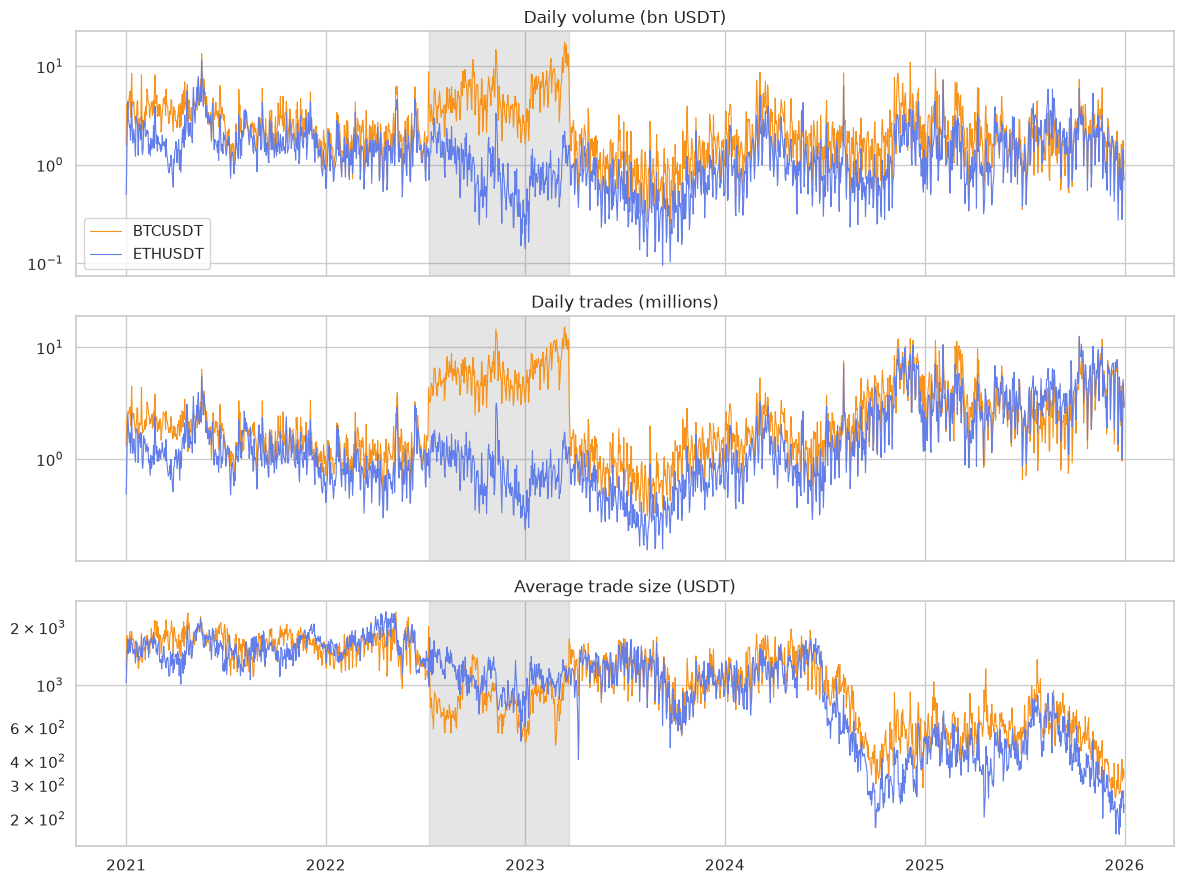

In [13]:
ZERO_FEE = (pd.Timestamp("2022-07-08", tz="UTC"), pd.Timestamp("2023-03-22", tz="UTC"))

daily_activity = {s: df[["quote_volume", "trades"]].resample("1D").sum() for s, df in data.items()}

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for s, d in daily_activity.items():
    axes[0].plot(d.index, d["quote_volume"] / 1e9, color=COLORS[s], lw=0.8, label=s)
    axes[1].plot(d.index, d["trades"] / 1e6, color=COLORS[s], lw=0.8)
    axes[2].plot(d.index, d["quote_volume"] / d["trades"], color=COLORS[s], lw=0.8)
for ax, title in zip(axes, ["Daily volume (bn USDT)", "Daily trades (millions)", "Average trade size (USDT)"]):
    ax.axvspan(*ZERO_FEE, color="grey", alpha=0.2)
    ax.set_yscale("log")
    ax.set_title(title)
axes[0].legend()
fig.tight_layout()
savefig(fig, "activity_over_time")

In [14]:
def period_label(ts):
    if ts < ZERO_FEE[0]:
        return "1 before"
    if ts < ZERO_FEE[1]:
        return "2 zero-fee"
    return "3 after"


rows = {}
for s, d in daily_activity.items():
    d = d.loc[:"2023-12-31"]
    g = d.groupby(d.index.map(period_label))
    rows[(s, "trades/day (M)")] = g["trades"].mean() / 1e6
    rows[(s, "volume/day (bn)")] = g["quote_volume"].mean() / 1e9
    rows[(s, "avg trade (USDT)")] = g["quote_volume"].sum() / g["trades"].sum()
pd.DataFrame(rows).T

timestamp                 1 before  2 zero-fee   3 after
BTCUSDT trades/day (M)      1.6339      6.2599    1.0373
        volume/day (bn)     2.7557      5.4475    1.2287
        avg trade (USDT) 1686.5637    870.2241 1184.4787
ETHUSDT trades/day (M)      1.1792      0.8707    0.5486
        volume/day (bn)     1.8956      0.9908    0.6197
        avg trade (USDT) 1607.5200   1137.8287 1129.5155

### Findings: data quality
- **Gaps:** 7 exchange outages, 14 missing hours, identical in both assets (exchange-wide maintenance), plus the 3 hidden outage bars found in Section 1.
- **Consistency:** no OHLC violations, taker volume never exceeds volume, VWAP always inside the bar's range, no bad prices. The only zero-volume bars are the hidden outage bars.
- **Continuity:** the median gap between open and previous close is ~1e-7, i.e. zero. Only 5 jumps > 0.1% (largest 0.34%), none after an outage. They are fast markets at the candle boundary, not errors.
- **Extreme moves are genuine.** Every top move hits both assets in the same direction with a 2–25× volume spike. Two stand out as **BTC-specific**: 2021-01-29 (+11.6% BTC vs +4.5% ETH) and 2021-02-08 (+8.6% vs +3.0%), the dates of the Musk "#bitcoin" bio change and Tesla's BTC purchase announcement. The rest coincide with market-wide crashes (2021-05-19, 2021-09-07, 2022-05-11 LUNA collapse).
- **Huge wicks are real liquidation cascades** (e.g. BTC traded 30,000–38,000 inside one hour on 2021-05-19; 2021-12-04 flash crash; 2025-10-10). Keep them, but a backtest must not assume a stop order filled at its exact price inside such a bar.
- **Structural break caused by the exchange, not the market.** During Binance's BTC zero-fee promotion, BTC trades/day went from 1.6M to 6.3M (3.8×), volume doubled and average trade size halved, while ETH (no promotion) activity *fell*. After it ended, BTC activity dropped below its old level. **BTC volume and trade counts are therefore not comparable across time**; any volume feature must be relative to recent history, never an absolute level.

## 3. Research sample: train split only (2021–2023)

From here on we only look at 2021–2023. Returns are **log returns** of close prices at several horizons, sampled **without overlap**.

In [15]:
train = {s: df.loc[:TRAIN_END] for s, df in data.items()}
close = pd.DataFrame({s: df["close"] for s, df in train.items()})
log_price = np.log(close)

HORIZONS = {"1h": "1h", "4h": "4h", "1d": "1D", "1w": "7D"}
PER_YEAR = {"1h": 24 * 365, "4h": 6 * 365, "1d": 365, "1w": 365 / 7}
rets = {h: log_price.resample(rule).last().diff().dropna() for h, rule in HORIZONS.items()}
r1h = rets["1h"]

{h: len(r) for h, r in rets.items()}

{'1h': 26279, '4h': 6569, '1d': 1094, '1w': 156}

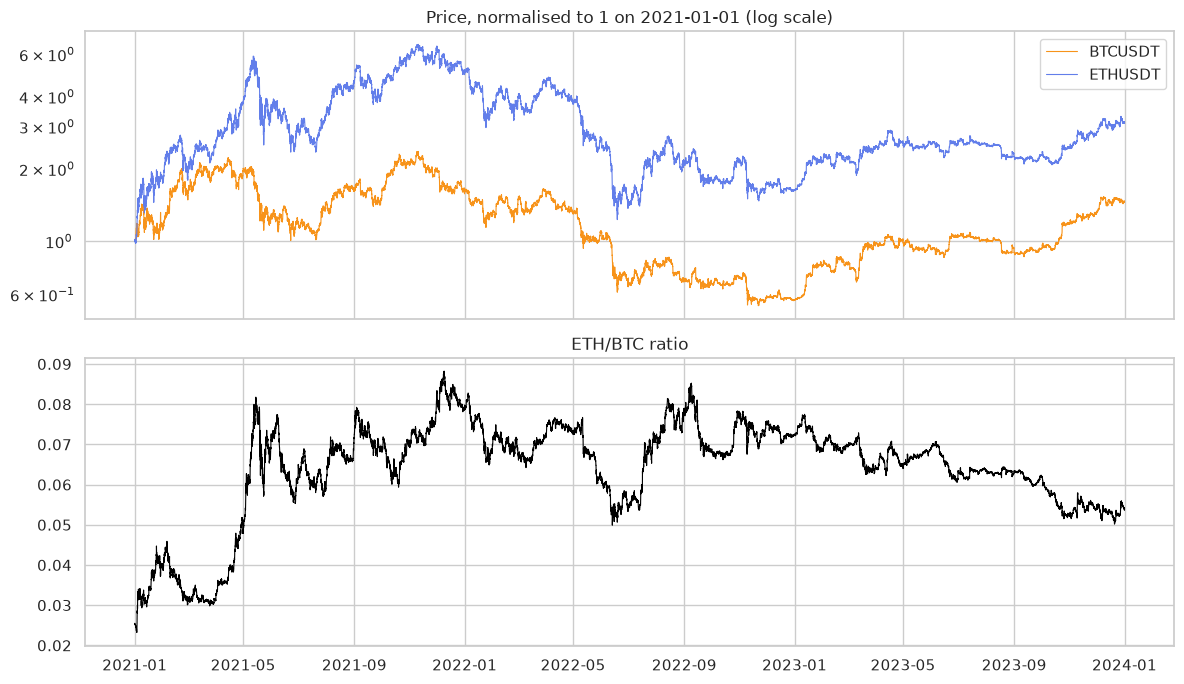

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for s in ASSETS:
    axes[0].plot(close.index, close[s] / close[s].iloc[0], color=COLORS[s], lw=0.8, label=s)
axes[0].set_yscale("log")
axes[0].set_title("Price, normalised to 1 on 2021-01-01 (log scale)")
axes[0].legend()
axes[1].plot(close.index, close["ETHUSDT"] / close["BTCUSDT"], color="black", lw=0.8)
axes[1].set_title("ETH/BTC ratio")
fig.tight_layout()
savefig(fig, "prices")

## 4. Return distributions

### 4.1 Summary statistics by horizon

In [17]:
def describe_returns(r, per_year):
    return pd.Series({
        "obs": len(r),
        "ann. mean %": r.mean() * per_year * 100,
        "ann. vol %": r.std() * np.sqrt(per_year) * 100,
        "skew": r.skew(),
        "excess kurtosis": r.kurt(),
        "min %": r.min() * 100,
        "max %": r.max() * 100,
        "Jarque-Bera p": stats.jarque_bera(r).pvalue,
    })


pd.DataFrame({(s, h): describe_returns(r[s], PER_YEAR[h]) for h, r in rets.items() for s in ASSETS})

,BTCUSDT,ETHUSDT,BTCUSDT,ETHUSDT,BTCUSDT,ETHUSDT,BTCUSDT,ETHUSDT
,1h,1h,4h,4h,1d,1d,1w,1w
obs,26279.0000,26279.0000,6569.0000,6569.0000,1094.0000,1094.0000,156.0000,156.0000
ann. mean %,12.5762,37.8063,12.2535,37.3259,12.2022,38.0748,2.3335,20.7957
ann. vol %,66.5485,84.6759,66.1917,83.8694,64.9110,85.0218,62.3149,77.7828
skew,-0.1897,-0.5908,-0.1173,-0.2402,-0.1779,-0.4024,-0.4619,-0.8118
excess kurtosis,15.7144,13.3851,7.9649,5.4432,3.5110,5.6707,3.1279,3.5142
min %,-9.3810,-14.0175,-11.1249,-12.7471,-16.6998,-32.4861,-38.9256,-51.5295
max %,11.6145,7.3611,13.7577,10.7388,17.8449,23.3750,26.1361,27.7718
Jarque-Bera p,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### 4.2 How fat are the tails?
Ratio of observed frequency of |z| > k to what a normal distribution predicts.

In [18]:
def tail_ratio(r):
    z = (r - r.mean()) / r.std()
    return pd.Series({f"|z| > {k}": (z.abs() > k).mean() / (2 * stats.norm.sf(k)) for k in [3, 4, 5, 6]})


pd.DataFrame({(s, h): tail_ratio(rets[h][s]) for h in ["1h", "1d"] for s in ASSETS})

,BTCUSDT,ETHUSDT,BTCUSDT,ETHUSDT
,1h,1h,1d,1d
|z| > 3,7.4562,7.2166,6.0943,5.4172
|z| > 4,135.1695,133.9680,72.1535,72.1535
|z| > 5,6504.7846,6969.4120,1594.4039,4783.2118
|z| > 6,1060689.2966,983548.2568,0.0000,463251.6873


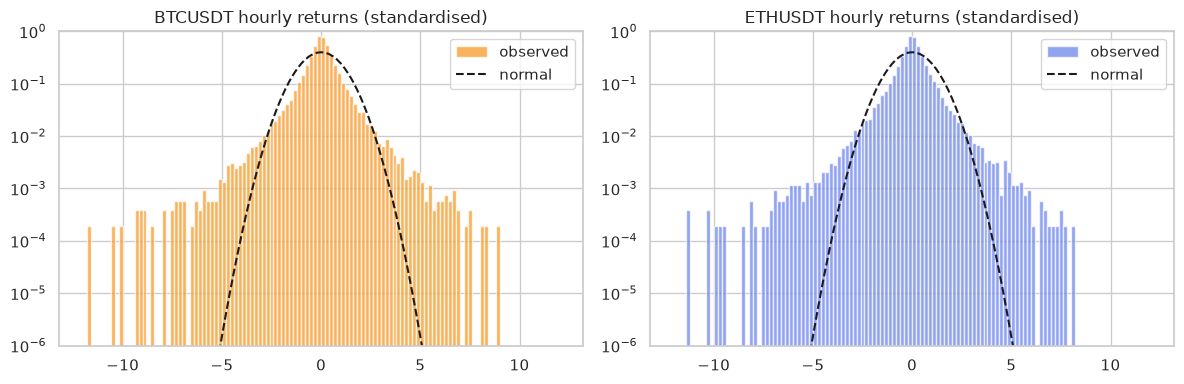

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, s in zip(axes, ASSETS):
    z = (r1h[s] - r1h[s].mean()) / r1h[s].std()
    bins = np.linspace(-12, 12, 121)
    ax.hist(z, bins=bins, density=True, color=COLORS[s], alpha=0.7, label="observed")
    ax.plot(bins, stats.norm.pdf(bins), "k--", label="normal")
    ax.set_yscale("log")
    ax.set_ylim(1e-6, 1)
    ax.set_title(f"{s} hourly returns (standardised)")
    ax.legend()
fig.tight_layout()
savefig(fig, "return_distribution")

### 4.3 Tail index (Hill estimator)
The tail index α describes how fast the tail decays: P(|r| > x) ~ x^(−α).
α < 4 means the kurtosis is not well defined (it keeps growing with more data); α < 2 would mean infinite variance.
Hill estimates depend on how much of the tail is used, so we show three cut-offs.

In [20]:
def hill_alpha(x, tail_frac):
    x = np.sort(x[x > 0])[::-1]
    k = int(len(x) * tail_frac)
    return 1 / np.mean(np.log(x[:k] / x[k]))


rows = {}
for s in ASSETS:
    for h in ["1h", "1d"]:
        r = rets[h][s].values
        for frac in [0.01, 0.025, 0.05]:
            rows[(s, h, frac)] = {"left tail α": hill_alpha(-r, frac), "right tail α": hill_alpha(r, frac)}
pd.DataFrame(rows).T

left tail α  right tail α
BTCUSDT 1h 0.0100       3.4381        3.6721
           0.0250       3.0101        3.0259
           0.0500       2.6580        2.6904
        1d 0.0100       5.4087        4.2133
           0.0250       3.7654        6.9713
           0.0500       2.7338        4.2939
ETHUSDT 1h 0.0100       3.0145        3.9968
           0.0250       3.0187        3.2641
           0.0500       2.6418        2.7877
        1d 0.0100       3.8710        2.5936
           0.0250       3.4267        4.1126
           0.0500       2.6042        3.4333

### 4.4 How much of the fat tail is just volatility clustering?
If we divide each return by a volatility estimate built **only from past data** (EWMA with a 1-week span, shifted by one bar), how much kurtosis is left?

In [21]:
ewma_vol = np.sqrt((r1h ** 2).ewm(span=24 * 7).mean().shift(1))
z_scaled = (r1h / ewma_vol).dropna()

pd.DataFrame({
    "raw excess kurtosis": r1h.kurt(),
    "vol-scaled excess kurtosis": z_scaled.kurt(),
    "raw skew": r1h.skew(),
    "vol-scaled skew": z_scaled.skew(),
})

,raw excess kurtosis,vol-scaled excess kurtosis,raw skew,vol-scaled skew
BTCUSDT,15.7144,24.7429,-0.1897,-0.0904
ETHUSDT,13.3851,18.0165,-0.5908,-0.5095


In [22]:
rows = {}
for s in ASSETS:
    nu, loc, scale = stats.t.fit(rets["1d"][s])
    rows[s] = {"Student-t degrees of freedom (daily)": nu}
pd.DataFrame(rows)

,BTCUSDT,ETHUSDT
Student-t degrees of freedom (daily),2.5425,2.9054


Scaling by past volatility made the kurtosis **larger**, not smaller. Which hours produce the most extreme vol-scaled shocks?

In [23]:
pd.DataFrame({
    "vol-scaled z": z_scaled["BTCUSDT"],
    "return %": r1h["BTCUSDT"] * 100,
    "previous hourly vol %": ewma_vol["BTCUSDT"] * 100,
}).loc[z_scaled["BTCUSDT"].abs().nlargest(8).index]

,vol-scaled z,return %,previous hourly vol %
timestamp,,,
2023-08-29 14:00:00+00:00,21.0292,5.3802,0.2558
2023-08-17 21:00:00+00:00,-19.3723,-5.2879,0.2730
2023-03-03 01:00:00+00:00,-13.6833,-5.5675,0.4069
2023-10-23 22:00:00+00:00,12.3795,5.1929,0.4195
2021-09-07 14:00:00+00:00,-12.1048,-6.5689,0.5427
2023-10-01 22:00:00+00:00,12.0014,2.9582,0.2465
2023-06-05 15:00:00+00:00,-11.5529,-3.0098,0.2605
2023-04-26 19:00:00+00:00,-11.5453,-6.4483,0.5585


In [24]:
# Sensitivity: different EWMA spans, and removing just the 5 largest shocks
rows = {}
for span in [24, 168, 720]:
    vol = np.sqrt((r1h ** 2).ewm(span=span).mean().shift(1))
    rows[f"EWMA span {span}h"] = (r1h / vol).kurt()
z_btc = z_scaled["BTCUSDT"]
print("BTC vol-scaled kurtosis without its 5 largest shocks:", round(z_btc.drop(z_btc.abs().nlargest(5).index).kurt(), 1))
pd.DataFrame(rows)

BTC vol-scaled kurtosis without its 5 largest shocks: 12.8


,EWMA span 24h,EWMA span 168h,EWMA span 720h
BTCUSDT,40.6203,24.7429,23.9318
ETHUSDT,24.2809,18.0165,21.6304


### Findings: distributions
- **Volatility level:** BTC ~65% a year, ETH ~85%. Annualised vol is almost the same at every horizon, which already hints that there is little autocorrelation to exploit (confirmed in Section 6).
- **Fat tails:** hourly excess kurtosis 13–16. Moves beyond 4σ happen ~130× more often than a normal distribution predicts. Tails thin with horizon (kurtosis 15.7 → 3.5 from hourly to daily for BTC) but are still clearly fat at weekly.
- **Negative skew**, stronger for ETH (−0.59 hourly vs −0.19): ETH's crashes are sharper.
- **Tail index α ≈ 2.6–3.7 hourly** (Student-t dof ≈ 2.5–2.9 daily): variance is finite, but the 4th moment probably isn't. Kurtosis numbers are therefore unstable estimates; don't build anything on their exact value.
- **Important: the biggest shocks come out of calm markets.** Dividing by past volatility *raises* kurtosis (BTC 15.7 → 24.7, and it holds for every EWMA span). The largest vol-scaled shocks are 5% hourly moves arriving when hourly volatility was ~0.25% (mostly in quiet 2023). Removing just 5 of them halves the kurtosis. So **jumps are not announced by rising volatility**.
- **Risk consequence:** volatility-scaled position sizing makes positions *largest* in calm markets, exactly where these unannounced jumps hit, and ATR-based stops will be gapped through. The risk layer needs a hard cap on exposure that does not depend on recent volatility.

## 5. Stationarity

- **ADF**: null = unit root (non-stationary). Small p → stationary.
- **KPSS**: null = stationary. Small p → non-stationary.

Using both guards against the low power of either one alone. Note: neither test checks whether the *variance* is constant; Section 7 does that.

In [25]:
def stationarity(x):
    return pd.Series({
        "ADF p": adfuller(x, autolag="AIC")[1],
        "KPSS p": kpss(x, regression="c", nlags="auto")[1],
    })


daily_log_price = log_price.resample("1D").last()
rows = {}
for s in ASSETS:
    rows[(s, "log price")] = stationarity(daily_log_price[s])
    rows[(s, "daily log return")] = stationarity(rets["1d"][s])
pd.DataFrame(rows).T

ADF p  KPSS p
BTCUSDT log price        0.5482  0.0100
        daily log return 0.0000  0.1000
ETHUSDT log price        0.1952  0.0100
        daily log return 0.0000  0.1000

### Findings: stationarity
Log prices are non-stationary (ADF can't reject a unit root, KPSS rejects stationarity); returns are stationary in the mean by both tests.
So models should work with returns (or other scale-free transforms), never raw price levels. The *variance* of returns is clearly not constant; see Section 7.

## 6. Serial dependence: do past returns tell us about future returns?

### 6.1 Autocorrelation of returns vs. absolute returns
The dashed band is the naive ±1.96/√n band. It is **too narrow** for heteroskedastic data, so small spikes in the return ACF are not proof of anything.

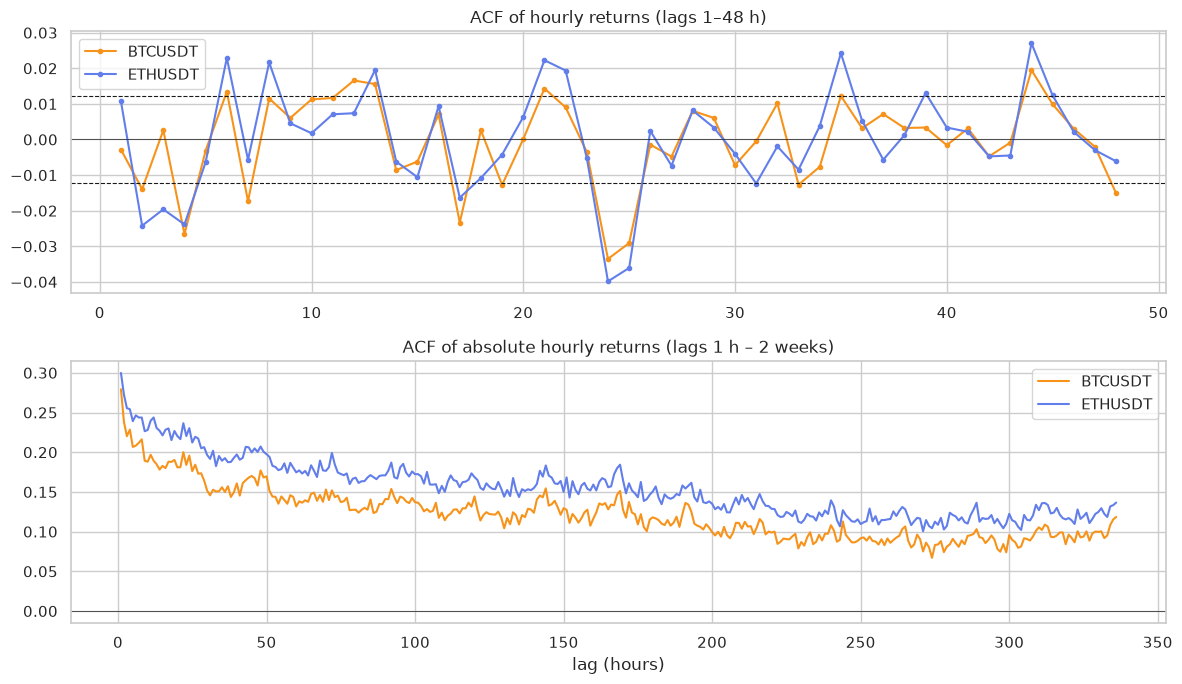

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for s in ASSETS:
    axes[0].plot(range(1, 49), acf(r1h[s], nlags=48)[1:], "o-", ms=3, color=COLORS[s], label=s)
    axes[1].plot(range(1, 24 * 14 + 1), acf(r1h[s].abs(), nlags=24 * 14)[1:], color=COLORS[s], label=s)
band = 1.96 / np.sqrt(len(r1h))
axes[0].axhline(band, ls="--", c="k", lw=0.8)
axes[0].axhline(-band, ls="--", c="k", lw=0.8)
axes[0].set_title("ACF of hourly returns (lags 1–48 h)")
axes[1].set_title("ACF of absolute hourly returns (lags 1 h – 2 weeks)")
axes[1].set_xlabel("lag (hours)")
for ax in axes:
    ax.axhline(0, c="k", lw=0.5)
    ax.legend()
fig.tight_layout()
savefig(fig, "acf")

### 6.2 Ljung-Box test (24 lags)
Tested on raw returns, on vol-scaled returns (which removes most of the heteroskedasticity that inflates the raw test), and on squared returns.

In [27]:
rows = {}
for s in ASSETS:
    series = {"returns": r1h[s], "vol-scaled returns": z_scaled[s], "squared returns": r1h[s] ** 2}
    rows[s] = {name: acorr_ljungbox(x, lags=[24])["lb_pvalue"].iloc[0] for name, x in series.items()}
pd.DataFrame(rows).T

,returns,vol-scaled returns,squared returns
BTCUSDT,0.0000,0.0006,0.0000
ETHUSDT,0.0000,0.0000,0.0000


### 6.3 Is the lag-1 autocorrelation stable across years?

In [28]:
rows = {}
for h in ["1h", "4h", "1d"]:
    for s in ASSETS:
        r = rets[h][s]
        rows[(s, h)] = r.groupby(r.index.year).apply(lambda x: x.autocorr(1))
lag1 = pd.DataFrame(rows).T
lag1["±2 s.e. (1 yr)"] = [2 / np.sqrt(len(rets[h]) / 3) for h in ["1h", "1h", "4h", "4h", "1d", "1d"]]
lag1

,timestamp,2021,2022,2023,±2 s.e. (1 yr)
BTCUSDT,1h,0.0033,0.0025,-0.0414,0.0214
ETHUSDT,1h,0.0179,0.0124,-0.0376,0.0214
BTCUSDT,4h,-0.0700,0.0158,0.0114,0.0427
ETHUSDT,4h,-0.0592,-0.0131,-0.0056,0.0427
BTCUSDT,1d,-0.0624,-0.0174,0.0083,0.1047
ETHUSDT,1d,-0.0898,-0.0116,-0.1071,0.1047


### 6.4 Variance ratio test: trending or mean-reverting?
VR(q) = Var(q-period return) / (q · Var(1-period return)).
- VR > 1 → returns persist (momentum / trend)
- VR < 1 → returns reverse (mean reversion)
- VR = 1 → random walk

The z-statistic is the Lo–MacKinlay version that stays valid under changing volatility.

In [29]:
def variance_ratio(r, q):
    r = r.dropna().values
    mu = r.mean()
    e2 = (r - mu) ** 2
    var1 = e2.sum() / (len(r) - 1)
    rq = np.convolve(r, np.ones(q), mode="valid")          # overlapping q-period sums
    m = q * (len(r) - q + 1) * (1 - q / len(r))
    vr = ((rq - q * mu) ** 2).sum() / m / var1

    theta = 0.0                                              # heteroskedasticity-robust variance
    for j in range(1, q):
        delta = (e2[j:] * e2[:-j]).sum() / e2.sum() ** 2
        theta += (2 * (q - j) / q) ** 2 * delta
    return vr, (vr - 1) / np.sqrt(theta)

In [30]:
rows = {}
for s in ASSETS:
    for q in [2, 4, 12, 24, 72, 168]:
        vr, z = variance_ratio(r1h[s], q)
        rows[(s, "hourly", q)] = {"VR": vr, "z": z}
    for q in [2, 5, 10, 20]:
        vr, z = variance_ratio(rets["1d"][s], q)
        rows[(s, "daily", q)] = {"VR": vr, "z": z}
pd.DataFrame(rows).T

VR       z
BTCUSDT hourly 2   0.9972 -0.2433
               4   0.9832 -0.7930
               12  0.9525 -1.1740
               24  0.9811 -0.3304
               72  0.9429 -0.6077
               168 0.9764 -0.1739
        daily  2   0.9659 -0.8965
               5   0.9975 -0.0320
               10  1.0096  0.0793
               20  1.0238  0.1348
ETHUSDT hourly 2   1.0107  0.8265
               4   0.9822 -0.7628
               12  0.9480 -1.1856
               24  0.9763 -0.3808
               72  0.9618 -0.3716
               168 0.9795 -0.1376
        daily  2   0.9422 -1.3341
               5   0.9517 -0.5126
               10  0.9254 -0.5174
               20  0.9042 -0.4681

In [31]:
# Same test, one year at a time: does the sign of the effect stay the same?
rows = {}
for s in ASSETS:
    for year in [2021, 2022, 2023]:
        r = r1h[s].loc[str(year)]
        rows[(s, year)] = {f"VR({q}h)": variance_ratio(r, q)[0] for q in [2, 24, 168]}
pd.DataFrame(rows).T

VR(2h)  VR(24h)  VR(168h)
BTCUSDT 2021  1.0034   0.9435    0.8314
        2022  1.0026   0.9983    1.0461
        2023  0.9588   1.0881    1.3391
ETHUSDT 2021  1.0180   0.9370    0.8495
        2022  1.0125   1.0318    1.1810
        2023  0.9626   0.9916    0.9219

### 6.5 Pearson vs. rank (Spearman) autocorrelation
Pearson correlation is dominated by the few huge moves; rank correlation weighs every hour equally.

In [32]:
pd.DataFrame({
    s: {
        "Pearson lag-1": r1h[s].autocorr(1),
        "Spearman lag-1": r1h[s].corr(r1h[s].shift(1), method="spearman"),
    }
    for s in ASSETS
})

,BTCUSDT,ETHUSDT
Pearson lag-1,-0.0028,0.0107
Spearman lag-1,-0.0505,-0.0384


### Findings: serial dependence
- **Returns:** Pearson autocorrelation is ≈ 0 at all lags; **absolute returns** are strongly autocorrelated for weeks, with bumps every 24 h (the intraday volatility cycle). Direction is close to unpredictable from its own past; size is very predictable.
- Ljung-Box rejects "no autocorrelation" even after vol-scaling, so *some* linear structure exists, but it's tiny.
- **Lag-1 autocorrelation is not stable:** hourly it's slightly positive in 2021–22 and −0.04 in 2023.
- **Variance ratios ≈ 1 at every horizon** with no significant z: over 2021–23 as a whole, neither trend-following nor mean reversion is visible in the return series.
- **Year by year the picture flips:** weekly VR(168h) for BTC is 0.83 (mean-reverting) in 2021, 1.05 in 2022, 1.34 (trending) in 2023. The market's "character" changes by regime, so a single fixed style will be fragile.
- **Rank vs Pearson:** Spearman lag-1 is −0.04 to −0.05 while Pearson is ≈ 0. **Ordinary-sized moves slightly reverse; the few huge moves don't**, and they dominate Pearson. That's why it matters which correlation you look at (followed up in Section 12).

## 7. Volatility

### 7.1 Volatility through time
30-day realised volatility from hourly returns, annualised.

,min,50%,max
BTCUSDT,22.0861,59.8369,135.4380
ETHUSDT,21.7584,73.8274,192.7529


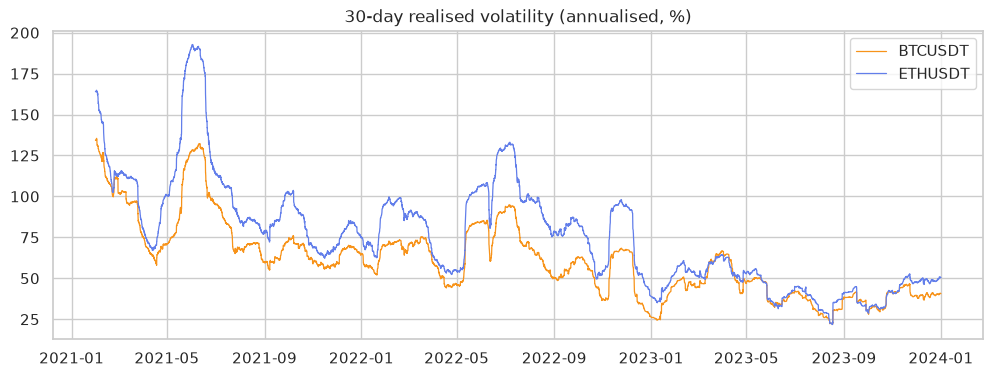

In [33]:
rv_30d = np.sqrt((r1h ** 2).rolling(24 * 30).sum() * 365 / 30) * 100

fig, ax = plt.subplots()
for s in ASSETS:
    ax.plot(rv_30d.index, rv_30d[s], color=COLORS[s], lw=0.9, label=s)
ax.set_title("30-day realised volatility (annualised, %)")
ax.legend()
savefig(fig, "realised_vol")

rv_30d.describe().T[["min", "50%", "max"]]

### 7.2 Daily realised variance and its persistence
Daily realised variance (RV) = sum of the 24 squared hourly returns. It is a much less noisy volatility measure than a single squared daily return.

,BTCUSDT,ETHUSDT
ACF lag 1d,0.6330,0.7108
ACF lag 7d,0.6085,0.6359
ACF lag 30d,0.3424,0.4155
ACF lag 90d,0.2557,0.3333


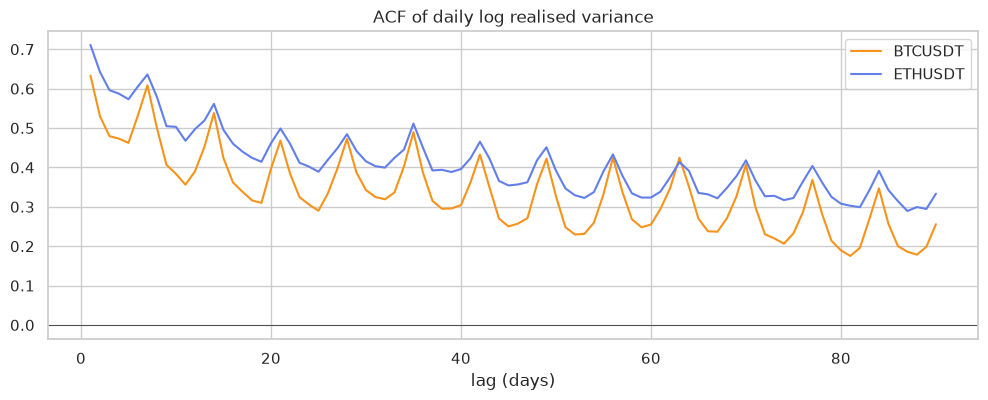

In [34]:
rv_daily = (r1h ** 2).resample("1D").sum()
log_rv = np.log(rv_daily)

fig, ax = plt.subplots()
for s in ASSETS:
    ax.plot(range(1, 91), acf(log_rv[s], nlags=90)[1:], color=COLORS[s], label=s)
ax.axhline(0, c="k", lw=0.5)
ax.set_title("ACF of daily log realised variance")
ax.set_xlabel("lag (days)")
ax.legend()
savefig(fig, "rv_persistence")

pd.DataFrame({s: {f"ACF lag {k}d": acf(log_rv[s], nlags=90)[k] for k in [1, 7, 30, 90]} for s in ASSETS})

### 7.3 Is volatility forecastable? HAR model, tested out of sample
HAR model: tomorrow's log RV = a + b·(today) + c·(last 7 days) + d·(last 30 days).
Fit on 2021–2022, evaluate on 2023. Compared against two naive forecasts: "tomorrow = today" and "tomorrow = 2021–22 average".

In [35]:
def har_frame(lrv):
    return pd.DataFrame({
        "day": lrv,
        "week": lrv.rolling(7).mean(),
        "month": lrv.rolling(30).mean(),
        "next_day": lrv.shift(-1),
    }).dropna()


rows = {}
for s in ASSETS:
    f = har_frame(log_rv[s])
    fit, test = f.loc[:"2022"], f.loc["2023"]
    X_cols = ["day", "week", "month"]
    model = sm.OLS(fit["next_day"], sm.add_constant(fit[X_cols])).fit()
    pred = model.predict(sm.add_constant(test[X_cols]))

    mse = lambda p: ((test["next_day"] - p) ** 2).mean()
    rows[s] = {
        "in-sample R²": model.rsquared,
        "2023 R² (vs 2021-22 mean)": 1 - mse(pred) / mse(fit["next_day"].mean()),
        "2023 MSE / naive 'same as today'": mse(pred) / mse(test["day"]),
        "b day": model.params["day"], "c week": model.params["week"], "d month": model.params["month"],
    }
pd.DataFrame(rows)

,BTCUSDT,ETHUSDT
in-sample R²,0.4506,0.4735
2023 R² (vs 2021-22 mean),0.5971,0.7293
2023 MSE / naive 'same as today',0.6567,0.6670
b day,0.2882,0.3660
c week,0.5093,0.4705
d month,0.1316,0.0618


### 7.4 GARCH: persistence and asymmetry
GJR-GARCH(1,1) with Student-t errors on daily returns. `gamma` measures asymmetry: a positive gamma means negative returns raise future volatility more than positive returns (the "leverage effect" seen in stocks).

In [36]:
rows = {}
for s in ASSETS:
    res = arch_model(rets["1d"][s] * 100, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="t").fit(disp="off")
    a, g, b = res.params["alpha[1]"], res.params["gamma[1]"], res.params["beta[1]"]
    persistence = a + b + g / 2
    rows[s] = {
        "alpha": a, "gamma": g, "gamma p-value": res.pvalues["gamma[1]"], "beta": b,
        "persistence": persistence,
        # half-life only exists if persistence < 1; at ~1 shocks never fade (integrated GARCH)
        "half-life (days)": np.log(0.5) / np.log(persistence) if persistence < 0.999 else np.inf,
        "t dof": res.params["nu"],
    }
pd.DataFrame(rows)

,BTCUSDT,ETHUSDT
alpha,0.0264,0.0452
gamma,-0.0013,0.0079
gamma p-value,0.9504,0.6823
beta,0.9743,0.9509
persistence,1.0000,1.0000
half-life (days),inf,inf
t dof,3.3534,3.9890


### 7.5 Do high/low prices add volatility information?
Compare three estimates of today's variance on how well they correlate with **tomorrow's** realised variance:
close-to-close squared return, Parkinson range estimator (uses high/low), and hourly RV.

In [37]:
rows = {}
for s in ASSETS:
    d1 = load(s, "1d").loc[:TRAIN_END]
    estimators = pd.DataFrame({
        "squared daily return": np.log(d1["close"]).diff() ** 2,
        "Parkinson (high/low)": np.log(d1["high"] / d1["low"]) ** 2 / (4 * np.log(2)),
        "hourly RV": rv_daily[s],
    })
    next_rv = np.log(rv_daily[s]).shift(-1)
    rows[s] = np.log(estimators.replace(0, np.nan)).corrwith(next_rv, method="spearman")
pd.DataFrame(rows)

,BTCUSDT,ETHUSDT
squared daily return,0.3784,0.4235
Parkinson (high/low),0.5786,0.6536
hourly RV,0.6199,0.6899


### Findings: volatility
- **Level shifts:** 30-day vol ranges from ~22% to 135% (BTC) and 193% (ETH), and the average level roughly halved from 2021 to 2023 (BTC 81% → 44%, ETH 109% → 47%; Section 9).
- **Strong persistence:** the autocorrelation of daily log realised variance is 0.63–0.71 at 1 day and still 0.26–0.33 at 90 days.
- **Volatility is forecastable, and it holds out of sample.** A HAR model fitted on 2021–22 cuts forecast error on 2023 by ~34% versus "tomorrow = today", with out-of-sample R² 0.60 (BTC) and 0.73 (ETH). The weekly component carries most of the weight. **This is the most robust, most usable structure found in the data**: good for position sizing and stop distances.
- **GARCH persistence ≈ 1 (integrated GARCH).** This is the classic symptom of a shifting volatility *level*, not of shocks that literally never fade. A single GARCH over 2021–23 is mis-specified; it's better to model vol with an explicitly slow-moving level (e.g. HAR's monthly term).
- **No leverage effect** (gamma ≈ 0, p = 0.95 / 0.68): unlike stocks, crypto volatility reacts about equally to up and down moves. Don't assume "vol rises only after falls".
- **Daily high/low carry real volatility information:** the Parkinson range estimator predicts tomorrow's RV almost as well as hourly RV (0.58 vs 0.62 BTC) and far better than the squared close-to-close return (0.38). With only daily bars, always use the range.

## 8. Intraday and weekly seasonality

### 8.1 Hour of day (UTC)

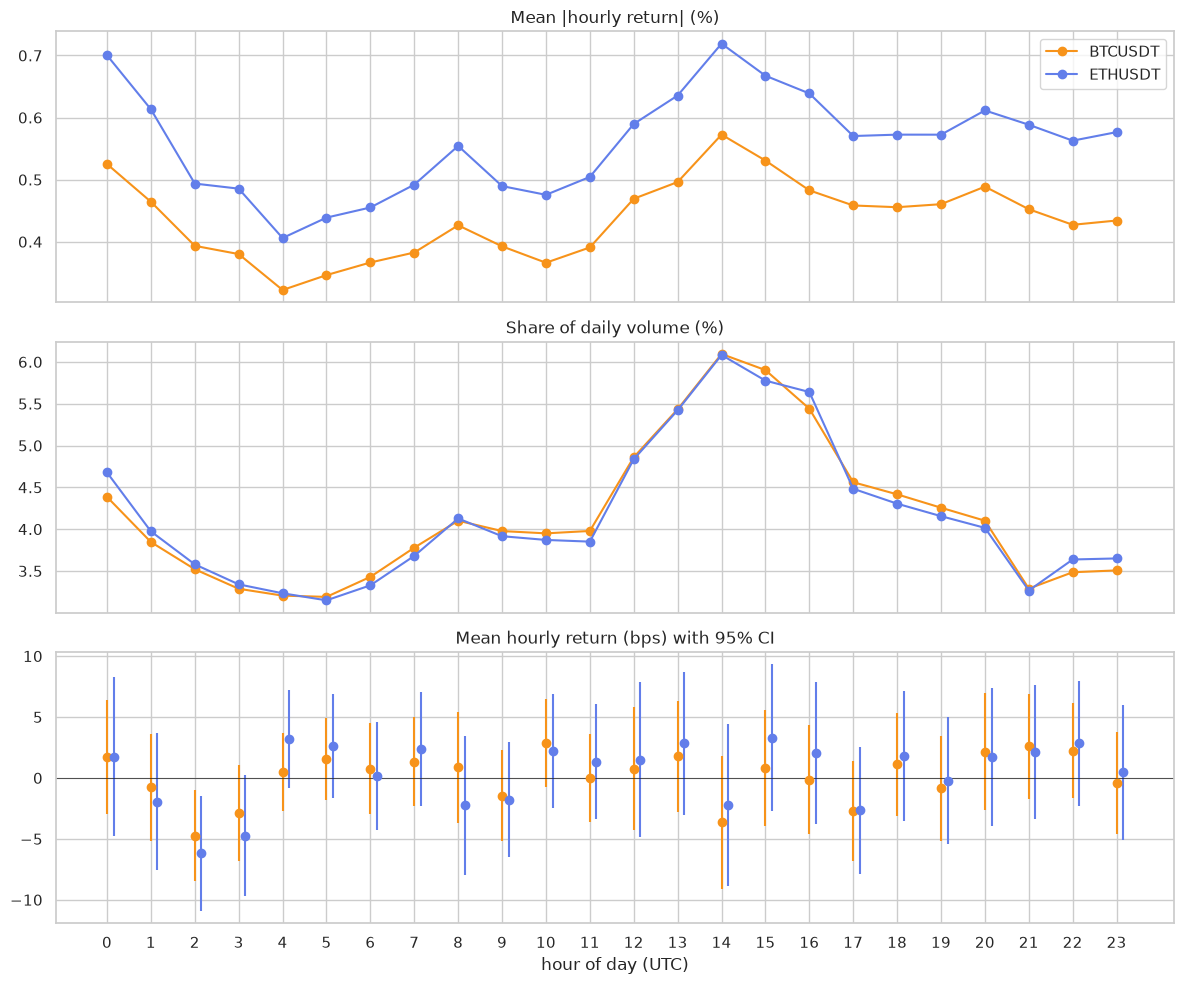

In [38]:
hour = r1h.index.hour
volume_share = {s: train[s]["quote_volume"] / train[s]["quote_volume"].resample("1D").transform("sum") for s in ASSETS}

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for s in ASSETS:
    axes[0].plot(r1h[s].abs().groupby(hour).mean() * 100, "o-", color=COLORS[s], label=s)
    axes[1].plot(volume_share[s].groupby(volume_share[s].index.hour).mean() * 100, "o-", color=COLORS[s])
    g = r1h[s].groupby(hour)
    mean, se = g.mean() * 1e4, g.std() / np.sqrt(g.count()) * 1e4
    axes[2].errorbar(mean.index + (0.15 if s == "ETHUSDT" else 0), mean, yerr=1.96 * se, fmt="o", color=COLORS[s])
axes[0].set_title("Mean |hourly return| (%)")
axes[1].set_title("Share of daily volume (%)")
axes[2].set_title("Mean hourly return (bps) with 95% CI")
axes[2].axhline(0, c="k", lw=0.5)
axes[2].set_xlabel("hour of day (UTC)")
axes[2].set_xticks(range(24))
axes[0].legend()
fig.tight_layout()
savefig(fig, "hour_of_day")

In [39]:
# Busiest and quietest hours (UTC) by average absolute return, relative to the daily average
for s in ASSETS:
    prof = r1h[s].abs().groupby(hour).mean()
    prof = prof / prof.mean()
    print(s, "most volatile:", prof.nlargest(3).round(2).to_dict(), "| quietest:", prof.nsmallest(3).round(2).to_dict())

BTCUSDT most volatile: {14: 1.31, 15: 1.21, 0: 1.2} | quietest: {4: 0.74, 5: 0.79, 10: 0.84}
ETHUSDT most volatile: {14: 1.29, 0: 1.25, 15: 1.19} | quietest: {4: 0.73, 5: 0.79, 6: 0.81}


**Stability test.** Build the 24-hour profile separately for 2021, 2022 and 2023 and correlate the profiles between years.
A real, persistent effect should have highly correlated profiles; noise should not.

In [40]:
def profile_correlation(x):
    profile = x.groupby([x.index.year, x.index.hour]).mean().unstack(0)
    c = profile.corr().values
    return c[np.triu_indices(3, k=1)].mean()


pd.DataFrame({
    s: {
        "|return| profile: mean corr between years": profile_correlation(r1h[s].abs()),
        "return profile: mean corr between years": profile_correlation(r1h[s]),
        "hours with |t| > 2 (return)": (np.abs(r1h[s].groupby(hour).mean() / (r1h[s].groupby(hour).std() / np.sqrt(r1h[s].groupby(hour).count()))) > 2).sum(),
        "expected by chance (5% of 24)": 1.2,
    }
    for s in ASSETS
})

,BTCUSDT,ETHUSDT
|return| profile: mean corr between years,0.6461,0.7114
return profile: mean corr between years,-0.1634,-0.1667
hours with |t| > 2 (return),1.0000,1.0000
expected by chance (5% of 24),1.2000,1.2000


### 8.2 Day of week

In [41]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
d1 = rets["1d"]
rows = {}
for s in ASSETS:
    g = d1[s].groupby(d1.index.dayofweek)
    daily_volume = train[s]["quote_volume"].resample("1D").sum()
    rows[(s, "mean |ret| %")] = d1[s].abs().groupby(d1.index.dayofweek).mean() * 100
    rows[(s, "mean ret %")] = g.mean() * 100
    rows[(s, "t-stat")] = g.mean() / (g.std() / np.sqrt(g.count()))
    rows[(s, "volume vs avg")] = daily_volume.groupby(daily_volume.index.dayofweek).mean() / daily_volume.mean()
weekday = pd.DataFrame(rows)
weekday.index = day_names
weekday

BTCUSDT                                       ETHUSDT                                 
    mean |ret| % mean ret %  t-stat volume vs avg mean |ret| % mean ret %  t-stat volume vs avg
Mon       2.9707    -0.0291 -0.0829        1.1063       3.5987    -0.0265 -0.0621        1.1032
Tue       2.3551     0.1373  0.5398        1.1136       2.8952     0.1862  0.5938        1.0960
Wed       2.7737     0.2559  0.8150        1.1335       3.7159     0.4227  0.9844        1.1440
Thu       2.5051    -0.2633 -0.9441        1.0768       3.3016    -0.1489 -0.3972        1.0823
Fri       2.6484    -0.0009 -0.0032        1.1136       3.3935    -0.1405 -0.3763        1.0516
Sat       1.2525     0.0066  0.0411        0.7195       2.0497     0.1410  0.5684        0.7557
Sun       1.7281     0.1270  0.6429        0.7394       2.4006     0.2948  1.0069        0.7699

### Findings: seasonality
- **Volatility has a daily rhythm:** the busiest hours are 14–15 UTC (US market open), ~30% above average, plus 00 UTC (start of the UTC day); the quietest are 04–06 UTC, ~25% below. The rhythm repeats from year to year: the |return| profiles of different years correlate 0.65–0.71. This is a robust structure, useful for scaling risk by hour and for choosing when to execute.
- **Returns have no reliable daily rhythm.** Year-to-year profiles are *negatively* correlated (−0.16), and only 1 hour out of 24 has |t| > 2, exactly what chance predicts (1.2). An "hour-of-day return" effect found in one year would be noise.
- **Weekends are quiet:** weekend volume is ~25% below average and Saturday's average absolute move is about half a weekday's. No weekday has a significant mean return (all |t| < 1.1).

## 9. Regimes and structural change

### 9.1 Year by year

In [42]:
def max_drawdown(price):
    return (price / price.cummax() - 1).min()


rows = {}
for s in ASSETS:
    for year in [2021, 2022, 2023]:
        r = rets["1d"][s].loc[str(year)]
        p = close[s].loc[str(year)]
        rows[(s, year)] = {
            "return %": (np.exp(r.sum()) - 1) * 100,
            "ann. vol %": r.std() * np.sqrt(365) * 100,
            "skew": r.skew(),
            "excess kurt": r.kurt(),
            "max drawdown %": max_drawdown(p) * 100,
            "daily lag-1 autocorr": r.autocorr(1),
            "avg daily volume (bn USDT)": train[s]["quote_volume"].loc[str(year)].resample("1D").sum().mean() / 1e9,
        }
pd.DataFrame(rows).T

return %  ann. vol %    skew  excess kurt  max drawdown %  daily lag-1 autocorr  avg daily volume (bn USDT)
BTCUSDT 2021   57.5665     81.0283 -0.0603       1.5303        -54.7225               -0.0624                      3.1629
        2022  -64.2071     64.4079 -0.5841       4.3895        -67.3771               -0.0174                      3.2860
        2023  155.6073     43.5694  0.7000       3.1178        -21.7408                0.0083                      2.5213
ETHUSDT 2021  404.3462    108.7407 -0.4740       4.3209        -60.1496               -0.0898                      2.1155
        2022  -67.4631     87.4240 -0.3479       2.6266        -76.6666               -0.0116                      1.2709
        2023   90.7711     46.5262  0.3607       2.2898        -28.1575               -0.1071                      0.6671

### 9.2 Buy-and-hold drawdowns
This is the benchmark the strategies have to beat, and a drawdown profile they should improve on.

,BTCUSDT,ETHUSDT
max drawdown %,-77.1985,-81.3430
date of max drawdown,2022-11-21,2022-06-18
longest underwater (days),781.2500,781.3333


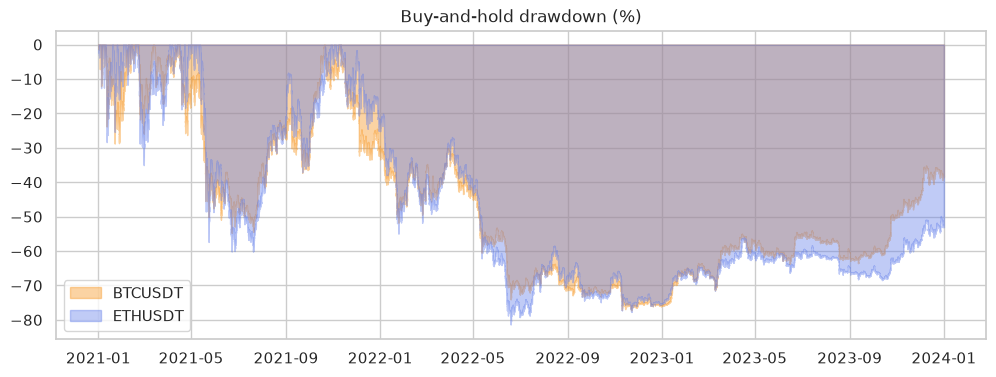

In [43]:
fig, ax = plt.subplots()
rows = {}
for s in ASSETS:
    dd = close[s] / close[s].cummax() - 1
    ax.fill_between(dd.index, dd * 100, 0, color=COLORS[s], alpha=0.4, label=s)
    underwater = (dd < 0).astype(int)
    longest = underwater.groupby((underwater == 0).cumsum()).sum().max() / 24
    rows[s] = {"max drawdown %": dd.min() * 100, "date of max drawdown": dd.idxmin().date(), "longest underwater (days)": longest}
ax.set_title("Buy-and-hold drawdown (%)")
ax.legend()
savefig(fig, "drawdowns")
pd.DataFrame(rows)

### 9.3 Volatility regimes
Each day is labelled low / mid / high vol using **yesterday's** 30-day realised vol (so the label is known before the day starts).
Tercile cut-offs use the whole train period, which is fine for description but would need an expanding window in a strategy.

In [44]:
daily_rv30 = np.sqrt(rv_daily.rolling(30).sum() * 365 / 30).shift(1)
d1 = rets["1d"]

rows = {}
for s in ASSETS:
    regime = pd.qcut(daily_rv30[s], 3, labels=["low vol", "mid vol", "high vol"])
    frame = pd.DataFrame({"ret": d1[s], "btc": d1["BTCUSDT"], "eth": d1["ETHUSDT"], "regime": regime}).dropna()
    for name, g in frame.groupby("regime", observed=True):
        rows[(s, name)] = {
            "days": len(g),
            "mean daily ret %": g["ret"].mean() * 100,
            "t-stat": g["ret"].mean() / g["ret"].std() * np.sqrt(len(g)),
            "daily vol %": g["ret"].std() * 100,
            "lag-1 autocorr": g["ret"].autocorr(1),
            "BTC-ETH corr": g["btc"].corr(g["eth"]),
        }
pd.DataFrame(rows).T

days  mean daily ret %  t-stat  daily vol %  lag-1 autocorr  BTC-ETH corr
BTCUSDT low vol  355.0000            0.1248  1.0198       2.3059          0.0004        0.8596
        mid vol  355.0000           -0.2687 -1.4990       3.3778          0.0340        0.8613
        high vol 355.0000            0.2032  0.9501       4.0293         -0.1374        0.8158
ETHUSDT low vol  355.0000            0.1853  1.3863       2.5179         -0.0814        0.8376
        mid vol  355.0000           -0.2829 -1.2194       4.3712         -0.0292        0.8612
        high vol 355.0000            0.2397  0.8318       5.4295         -0.0937        0.8208

### 9.4 Trend regimes
Label each day by whether the close is above or below its 200-day moving average (known at that day's close), then look at the **next** day.

In [45]:
daily_close = close.resample("1D").last()
rows = {}
for s in ASSETS:
    above = (daily_close[s] > daily_close[s].rolling(200).mean()).where(daily_close[s].rolling(200).count() == 200)
    frame = pd.DataFrame({"next_ret": d1[s].shift(-1), "above": above}).dropna()
    for flag, g in frame.groupby("above"):
        rows[(s, "above 200d MA" if flag else "below 200d MA")] = {
            "days": len(g),
            "mean next-day ret %": g["next_ret"].mean() * 100,
            "t-stat": g["next_ret"].mean() / g["next_ret"].std() * np.sqrt(len(g)),
            "next-day vol %": g["next_ret"].std() * 100,
        }
pd.DataFrame(rows).T

days  mean next-day ret %  t-stat  next-day vol %
BTCUSDT below 200d MA 483.0000               0.0034  0.0229          3.2508
        above 200d MA 412.0000               0.0726  0.5421          2.7194
ETHUSDT below 200d MA 442.0000              -0.1263 -0.6253          4.2456
        above 200d MA 453.0000               0.1733  1.1219          3.2874

### Findings: regimes
- **Three very different years:** 2021 bull (BTC +58%, ETH +404%), 2022 bear (−64%, −67%), 2023 recovery (+156%, +91%). Volatility halved over the period, and daily skew flipped from negative (2021–22) to positive (2023). The train set covers bull, bear and recovery, which is good for robustness, but only one of each.
- **Buy-and-hold is brutal:** max drawdown −77% (BTC) and −81% (ETH), and both were still below their 2021 peaks at the end of 2023 (~780 days underwater). A strategy that simply avoids most of 2022 has a large advantage on drawdown-based scoring.
- **Vol regimes don't predict direction:** no mean return difference is significant (all |t| < 1.5). BTC–ETH correlation is a little *lower* in high-vol regimes (0.82 vs 0.86). BTC's daily lag-1 autocorrelation in high-vol regimes is −0.14 (≈ −2.6 s.e.), a hint of mean reversion in stressed markets. It's a single, unconfirmed result, so treat it as a hypothesis to test, not a finding.
- **200-day MA regime:** next-day returns above vs below the MA are not significantly different (|t| ≤ 1.1), but volatility is clearly lower above the MA (2.7% vs 3.3% daily for BTC). **A trend filter is more useful as a risk switch than as a return predictor.**

## 10. Volume, trades and order-flow variables

Hourly variables built from each candle (real bars only):
- `range`: log(high/low), an intrabar volatility measure
- `log_volume`, `log_trades`: activity
- `avg_trade`: USDT per trade
- `taker_buy_ratio`: share of volume from aggressive buyers (0.5 = balanced)
- `amihud`: |return| per $1M traded (illiquidity: how much price moves per unit of volume)

In [46]:
def bar_variables(df):
    real = df[~df["is_filled"] & (df["trades"] > 0)]         # also drop the hidden outage bars
    ret = np.log(df["close"]).diff().loc[real.index]
    return pd.DataFrame({
        "ret": ret,
        "abs_ret": ret.abs(),
        "range": np.log(real["high"] / real["low"]),
        "log_volume": np.log(real["quote_volume"]),
        "log_trades": np.log(real["trades"]),
        "avg_trade": real["quote_volume"] / real["trades"],
        "taker_buy_ratio": real["taker_buy_base"] / real["volume"],
        "amihud": ret.abs() / real["quote_volume"] * 1e6,
    })


bars = {s: bar_variables(df) for s, df in train.items()}
bars["BTCUSDT"].describe().T

,count,mean,std,min,25%,50%,75%,max
ret,26263.0000,0.0000,0.0071,-0.0938,-0.0025,0.0000,0.0026,0.1161
abs_ret,26263.0000,0.0044,0.0056,0.0000,0.0011,0.0026,0.0055,0.1161
range,26264.0000,0.0096,0.0087,0.0002,0.0044,0.0073,0.0120,0.2364
log_volume,26264.0000,18.2566,0.8954,12.5853,17.6522,18.3036,18.8739,21.8238
log_trades,26264.0000,11.1659,0.8790,5.4116,10.4968,11.0432,11.7963,14.1816
avg_trade,26264.0000,1291.7436,478.2980,286.6588,893.7429,1259.1173,1638.7282,5241.6103
taker_buy_ratio,26264.0000,0.4913,0.0411,0.1726,0.4700,0.4938,0.5136,0.7335
amihud,26263.0000,0.0000,0.0001,0.0000,0.0000,0.0000,0.0001,0.0047


### 10.1 Which variables are redundant?
Spearman (rank) correlations between the variables within the same hour.

,ret,abs_ret,range,log_volume,log_trades,avg_trade,taker_buy_ratio,amihud
ret,1.0000,0.0100,-0.0000,-0.0000,-0.0100,0.0000,0.4900,0.0100
abs_ret,0.0100,1.0000,0.7300,0.4200,0.2900,0.3900,0.0600,0.6800
range,-0.0000,0.7300,1.0000,0.6200,0.4300,0.5700,0.0700,0.2500
log_volume,-0.0000,0.4200,0.6200,1.0000,0.9200,0.2400,0.1200,-0.3200
log_trades,-0.0100,0.2900,0.4300,0.9200,1.0000,-0.1200,0.1400,-0.4000
avg_trade,0.0000,0.3900,0.5700,0.2400,-0.1200,1.0000,-0.0000,0.1900
taker_buy_ratio,0.4900,0.0600,0.0700,0.1200,0.1400,-0.0000,1.0000,-0.0400
amihud,0.0100,0.6800,0.2500,-0.3200,-0.4000,0.1900,-0.0400,1.0000


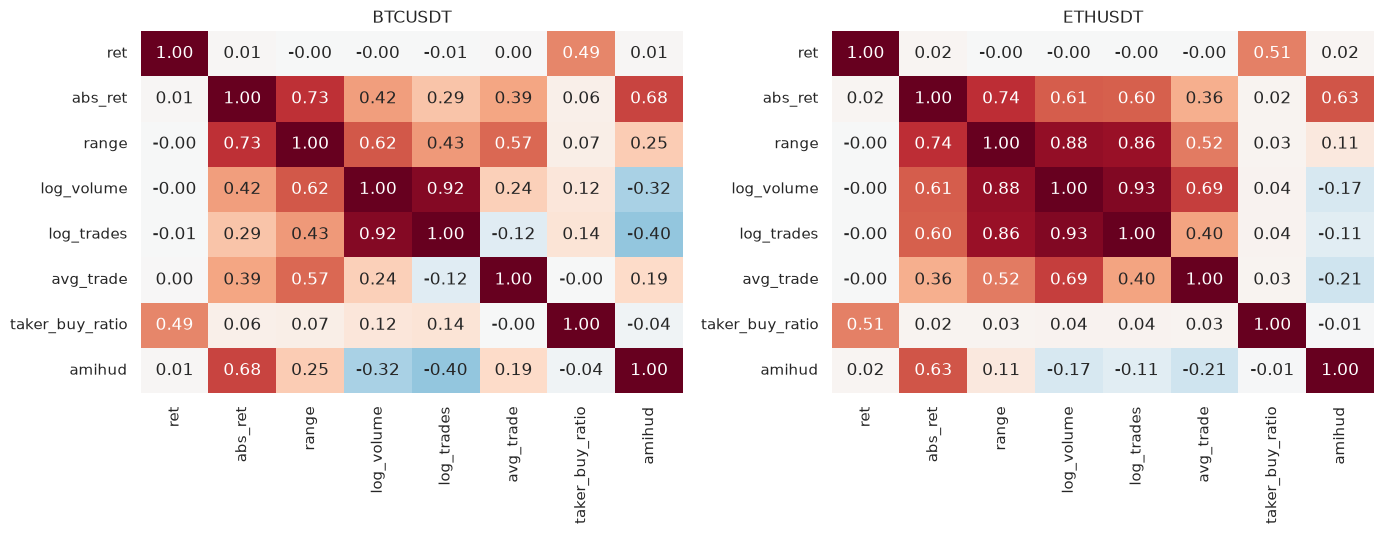

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, s in zip(axes, ASSETS):
    sns.heatmap(bars[s].corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, cbar=False)
    ax.set_title(s)
fig.tight_layout()
savefig(fig, "variable_correlations")

bars["BTCUSDT"].corr(method="spearman").round(2)

### 10.2 Taker buy ratio: contemporaneous vs. predictive
The taker buy ratio should be strongly tied to the **same hour's** return (aggressive buying moves price up), but that is useless for trading.
What matters is its link to the **next** hour's return.

In [48]:
rows = {}
for s in ASSETS:
    b = bars[s]
    next_ret = b["ret"].shift(-1)
    rows[s] = {
        "corr with same-hour return": b["taker_buy_ratio"].corr(b["ret"], method="spearman"),
        "corr with next-hour return": b["taker_buy_ratio"].corr(next_ret, method="spearman"),
        "mean ratio": b["taker_buy_ratio"].mean(),
    }
pd.DataFrame(rows)

,BTCUSDT,ETHUSDT
corr with same-hour return,0.4910,0.5078
corr with next-hour return,-0.0444,-0.0254
mean ratio,0.4913,0.4975


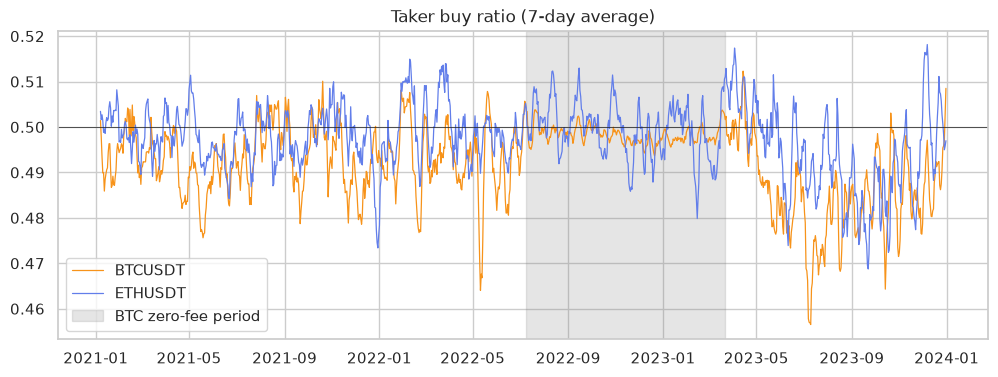

In [49]:
fig, ax = plt.subplots()
for s in ASSETS:
    daily_ratio = train[s]["taker_buy_base"].resample("1D").sum() / train[s]["volume"].resample("1D").sum()
    ax.plot(daily_ratio.rolling(7).mean(), color=COLORS[s], lw=0.9, label=s)
ax.axvspan(*ZERO_FEE, color="grey", alpha=0.2, label="BTC zero-fee period")
ax.axhline(0.5, c="k", lw=0.5)
ax.set_title("Taker buy ratio (7-day average)")
ax.legend()
savefig(fig, "taker_ratio")

In [50]:
# Average taker buy ratio before / during / after the BTC zero-fee period
pd.DataFrame({
    s: bars[s]["taker_buy_ratio"].groupby(bars[s].index.map(period_label)).mean()
    for s in ASSETS
})

,BTCUSDT,ETHUSDT
timestamp,,
1 before,0.4929,0.4992
2 zero-fee,0.4983,0.4992
3 after,0.4819,0.4927


### Findings: volume and order flow
- **Redundant variables:** `log_volume` and `log_trades` are 0.92 rank-correlated; keep one. `range` overlaps heavily with `abs_ret` (0.73) and volume (0.62). The activity variables mostly measure *one* thing: how busy/volatile the hour is.
- **Taker buy ratio is the only variable tied to direction:** 0.49–0.51 with the *same hour's* return. That's mechanical: aggressive buying is what pushes price up. With the *next* hour it's slightly **negative** (−0.04 / −0.03): after a burst of aggressive buying, price gives a little back.
- **Taker ratio is also affected by the exchange's fee policy:** BTC's average fell from 0.498 (zero-fee period) to 0.482 after it ended, while ETH barely moved. Use it relative to its own recent average, not as an absolute level.
- **Amihud illiquidity** (|return| per $ traded) is mostly |return| in disguise (0.68 correlation).

## 11. BTC and ETH together

### 11.1 Correlation by horizon

In [51]:
pd.Series({h: r["BTCUSDT"].corr(r["ETHUSDT"]) for h, r in rets.items()}, name="BTC-ETH correlation")

1h   0.8548
4h   0.8487
1d   0.8236
1w   0.8282
Name: BTC-ETH correlation, dtype: float64

### 11.2 Is the relationship stable? Rolling correlation and beta
30-day windows of hourly returns. Beta = how much ETH moves per 1% BTC move.

,mean,min,25%,75%,max
correlation,0.8677,0.6838,0.8470,0.8985,0.9483
beta,1.0671,0.7085,0.9367,1.1973,1.4132


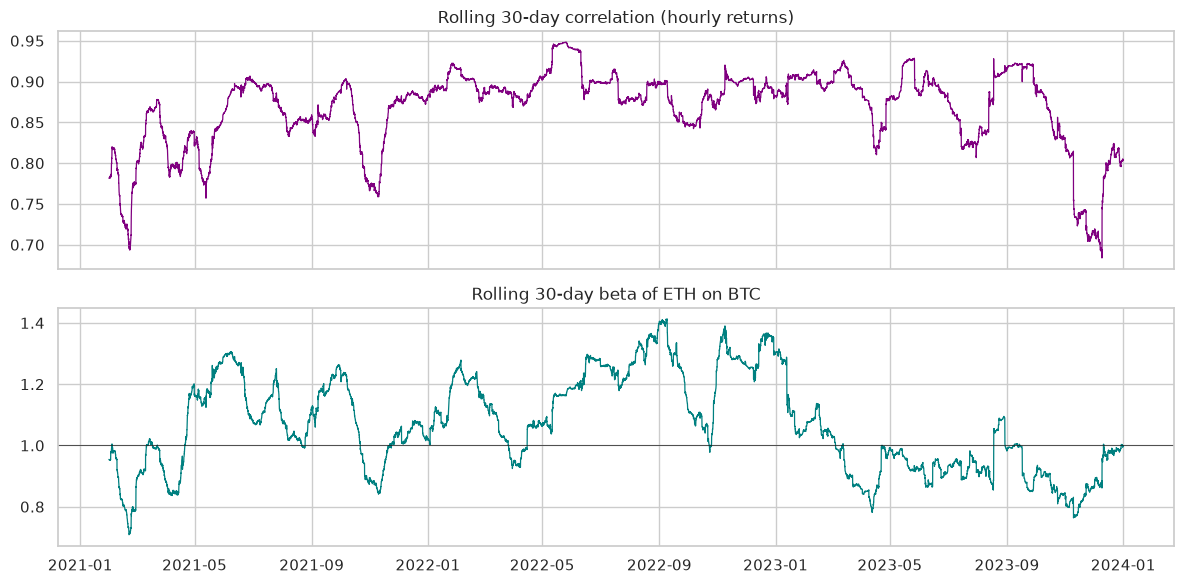

In [52]:
window = 24 * 30
roll_corr = r1h["BTCUSDT"].rolling(window).corr(r1h["ETHUSDT"])
roll_beta = r1h["BTCUSDT"].rolling(window).cov(r1h["ETHUSDT"]) / r1h["BTCUSDT"].rolling(window).var()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(roll_corr, color="purple", lw=0.9)
axes[0].set_title("Rolling 30-day correlation (hourly returns)")
axes[1].plot(roll_beta, color="teal", lw=0.9)
axes[1].axhline(1, c="k", lw=0.5)
axes[1].set_title("Rolling 30-day beta of ETH on BTC")
fig.tight_layout()
savefig(fig, "rolling_corr_beta")

pd.DataFrame({"correlation": roll_corr, "beta": roll_beta}).describe().T[["mean", "min", "25%", "75%", "max"]]

### 11.3 Lead-lag: does one asset move first?
Correlation of BTC's return in hour *t* with ETH's return in hour *t + k*. Positive k = BTC leads.

In [53]:
lead_lag = pd.Series({k: r1h["BTCUSDT"].corr(r1h["ETHUSDT"].shift(-k)) for k in range(-3, 4)}, name="corr(BTC_t, ETH_t+k)")
print("approx. 2 s.e.:", round(2 / np.sqrt(len(r1h)), 4))
lead_lag

approx. 2 s.e.: 0.0123


-3   -0.0089
-2   -0.0189
-1    0.0056
0     0.8548
1     0.0021
2    -0.0205
3    -0.0078
Name: corr(BTC_t, ETH_t+k), dtype: float64

### 11.4 Tail dependence: do they crash together more than correlation implies?
P(ETH in its worst q% | BTC in its worst q%), compared with a bivariate normal distribution having the **same correlation**.

In [54]:
def co_exceedance(x, y, q):
    lower = ((x <= np.quantile(x, q)) & (y <= np.quantile(y, q))).mean() / q
    upper = ((x >= np.quantile(x, 1 - q)) & (y >= np.quantile(y, 1 - q))).mean() / q
    return lower, upper


rng = np.random.default_rng(0)
rows = {}
for h in ["1h", "1d"]:
    x, y = rets[h]["BTCUSDT"].values, rets[h]["ETHUSDT"].values
    rho = np.corrcoef(x, y)[0, 1]
    sim = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=1_000_000)
    for q in [0.05, 0.01]:
        lo, up = co_exceedance(x, y, q)
        lo_n, up_n = co_exceedance(sim[:, 0], sim[:, 1], q)
        rows[(h, q)] = {"crash together": lo, "normal would give": lo_n, "rally together": up, "normal would give ": up_n}
pd.DataFrame(rows).T

crash together  normal would give  rally together  normal would give 
1h 0.0500          0.6888             0.5712          0.5997              0.5656
   0.0100          0.6507             0.4556          0.5023              0.4548
1d 0.0500          0.6947             0.5248          0.5119              0.5240
   0.0100          0.8227             0.4113          0.2742              0.4188

### 11.5 The ETH/BTC ratio: mean-reverting or not?
If log(ETH) and log(BTC) were cointegrated, the ratio would be a tradable mean-reverting spread.

In [55]:
log_ratio = daily_log_price["ETHUSDT"] - daily_log_price["BTCUSDT"]
ratio_ret = log_ratio.diff().dropna()

print("ADF p-value on log(ETH/BTC):", round(adfuller(log_ratio, autolag="AIC")[1], 3))
print("Engle-Granger cointegration p-value:", round(coint(daily_log_price["ETHUSDT"], daily_log_price["BTCUSDT"])[1], 3))
for year in [2021, 2022, 2023]:
    print(f"  {year}: ADF p on log ratio = {adfuller(log_ratio.loc[str(year)], autolag='AIC')[1]:.3f}")
pd.DataFrame({q: variance_ratio(ratio_ret, q) for q in [2, 5, 10, 20]}, index=["VR", "z"]).T

ADF p-value on log(ETH/BTC): 0.017
Engle-Granger cointegration p-value: 0.054
  2021: ADF p on log ratio = 0.475
  2022: ADF p on log ratio = 0.195
  2023: ADF p on log ratio = 0.687


,VR,z
2,0.9826,-0.3718
5,0.9684,-0.3243
10,1.0042,0.0282
20,1.1211,0.5640


### 11.6 How much of ETH is just BTC?
Share of ETH's variance explained by BTC (R² of ETH on BTC) at each horizon, and the behaviour of the leftover ("idiosyncratic") ETH return.

In [56]:
rows = {}
for h in ["1h", "1d"]:
    r = rets[h]
    beta = r["BTCUSDT"].cov(r["ETHUSDT"]) / r["BTCUSDT"].var()
    resid = r["ETHUSDT"] - beta * r["BTCUSDT"]
    rows[h] = {
        "beta": beta,
        "R² (share explained by BTC)": r["BTCUSDT"].corr(r["ETHUSDT"]) ** 2,
        "residual ann. vol %": resid.std() * np.sqrt(PER_YEAR[h]) * 100,
        "residual lag-1 autocorr": resid.autocorr(1),
    }
pd.DataFrame(rows)

,1h,1d
beta,1.0877,1.0788
R² (share explained by BTC),0.7308,0.6784
residual ann. vol %,43.9368,48.2164
residual lag-1 autocorr,0.0075,-0.0107


### Findings: BTC and ETH together
- **One dominant common factor:** correlation 0.82–0.85 at every horizon; BTC explains 68–73% of ETH's variance. ETH is roughly "1.08× BTC plus its own ~45%-vol noise", and that noise has no autocorrelation.
- **The link moves over time:** rolling 30-day correlation ranges 0.68–0.95 and beta 0.71–1.41. Hedge ratios and cross-asset risk limits must be estimated on rolling windows.
- **No lead-lag at hourly resolution:** BTC→ETH and ETH→BTC at ±1 h are ≈ 0 (well inside ±2 s.e.). A small negative correlation at ±2 h (−0.02) in both directions is the shared reversal from Section 6, not one asset leading. Any real lead-lag in crypto lives at seconds–minutes, which hourly data can't see.
- **They crash together much more than they rally together.** In the worst 1% of days, ETH is also in its worst 1% 82% of the time, vs 41% if the pair were normally distributed with the same correlation. For the best 1% it's only 27% (normal: 42%). Hourly shows the same asymmetry (65% vs 46% for crashes). **Diversification between BTC and ETH disappears exactly when it's needed.** Portfolio risk must assume ~100% correlation in crashes.
- **The ETH/BTC ratio looks mean-reverting only on the full sample.** Full-sample ADF p = 0.017 and cointegration p = 0.054 look promising, but within *every single year* ADF p ≥ 0.19. The full-sample result comes from one round trip (ratio up in 2021, back down in 2022–23). **A pairs trade on this would be fitting a single historical episode.**

## 12. Predictive information

Which variables, known at the close of hour *t*, say anything about returns from *t* to *t + h*?

**Method**
- Predictors are all built from data up to and including hour *t*.
- Targets are forward log returns over 1 h, 4 h and 24 h.
- Information coefficient (IC) = Spearman rank correlation between predictor and target.
- For horizon *h* we keep only every *h*-th observation, so targets don't overlap and the t-statistic (≈ IC·√n) is honest.
- Each IC is also computed per year: a real effect should keep the same sign.

In [57]:
def predictors(df, other):
    lp = np.log(df["close"])
    r = lp.diff()
    X = pd.DataFrame(index=df.index)
    for h in [1, 4, 24, 168, 720]:
        X[f"mom_{h}h"] = lp - lp.shift(h)
    X["rv_24h"] = np.sqrt((r ** 2).rolling(24).sum())
    X["rv_ratio_24h_30d"] = X["rv_24h"] / np.sqrt((r ** 2).rolling(720).sum() / 30)
    log_vol = np.log(df["quote_volume"] + 1)
    X["volume_surprise"] = log_vol - log_vol.rolling(168).mean()
    X["taker_ratio_1h"] = df["taker_buy_base"] / df["volume"]
    X["taker_ratio_24h"] = df["taker_buy_base"].rolling(24).sum() / df["volume"].rolling(24).sum()
    X["range_1h"] = np.log(df["high"] / df["low"])
    X["dist_ma_200h"] = lp - lp.rolling(200).mean()
    X["other_ret_1h"] = np.log(other["close"]).diff()
    return X


def targets(df, horizons=(1, 4, 24)):
    lp = np.log(df["close"])
    return pd.DataFrame({f"fwd_{h}h": lp.shift(-h) - lp for h in horizons})

In [58]:
def ic_table(X, Y, absolute=False):
    rows = []
    for target in Y:
        h = int(target.split("_")[1][:-1])
        y = Y[target].abs() if absolute else Y[target]
        for feature in X:
            d = pd.concat([X[feature], y], axis=1).dropna().iloc[::h]      # non-overlapping
            ic = d.corr(method="spearman").iloc[0, 1]
            by_year = d.groupby(d.index.year).apply(lambda g: g.corr(method="spearman").iloc[0, 1])
            rows.append({
                "feature": feature, "target": target, "IC": ic, "t": ic * np.sqrt(len(d)),
                **{str(y_): v for y_, v in by_year.items()},
                "same sign every year": bool((np.sign(by_year) == np.sign(ic)).all()),
            })
    return pd.DataFrame(rows)


X = {s: predictors(train[s], train[o]) for s, o in [("BTCUSDT", "ETHUSDT"), ("ETHUSDT", "BTCUSDT")]}
Y = {s: targets(train[s]) for s in ASSETS}

### 12.1 Direction: do predictors forecast the sign/size of future returns?
Sorted by |t|.

In [59]:
ic_direction = {s: ic_table(X[s], Y[s]) for s in ASSETS}
ic_direction["BTCUSDT"].sort_values("t", key=abs, ascending=False).head(12)

,feature,target,IC,t,2021,2022,2023,same sign every year
1,mom_4h,fwd_1h,-0.0700,-11.3489,-0.0667,-0.0606,-0.0818,True
0,mom_1h,fwd_1h,-0.0505,-8.1821,-0.0148,-0.0652,-0.0900,True
8,taker_ratio_1h,fwd_1h,-0.0445,-7.2096,-0.0174,-0.0513,-0.0731,True
12,other_ret_1h,fwd_1h,-0.0412,-6.6755,-0.0076,-0.0513,-0.0842,True
2,mom_24h,fwd_1h,-0.0371,-6.0041,-0.0400,-0.0281,-0.0428,True
14,mom_4h,fwd_4h,-0.0711,-5.7639,-0.0611,-0.0721,-0.0882,True
15,mom_24h,fwd_4h,-0.0583,-4.7194,-0.0681,-0.0337,-0.0822,True
10,range_1h,fwd_1h,0.0179,2.9028,0.0388,0.0005,0.0204,True
13,mom_1h,fwd_4h,-0.0356,-2.8840,-0.0194,-0.0407,-0.0631,True
9,taker_ratio_24h,fwd_1h,-0.0159,-2.5800,-0.0151,-0.0112,-0.0099,True


In [60]:
ic_direction["ETHUSDT"].sort_values("t", key=abs, ascending=False).head(12)

,feature,target,IC,t,2021,2022,2023,same sign every year
1,mom_4h,fwd_1h,-0.0538,-8.7243,-0.0448,-0.0488,-0.0796,True
12,other_ret_1h,fwd_1h,-0.0440,-7.1374,-0.0119,-0.0539,-0.0834,True
0,mom_1h,fwd_1h,-0.0384,-6.2303,-0.0064,-0.0467,-0.0815,True
2,mom_24h,fwd_1h,-0.0279,-4.5195,-0.0300,-0.0098,-0.0657,True
14,mom_4h,fwd_4h,-0.0533,-4.3156,-0.0486,-0.0511,-0.0644,True
10,range_1h,fwd_1h,0.0254,4.1117,0.0401,0.0100,0.0191,True
8,taker_ratio_1h,fwd_1h,-0.0252,-4.0836,-0.0148,-0.0176,-0.0493,True
5,rv_24h,fwd_1h,0.0214,3.4681,0.0358,0.0072,0.0164,True
15,mom_24h,fwd_4h,-0.0414,-3.3573,-0.0485,-0.0104,-0.1097,True
18,rv_24h,fwd_4h,0.0395,3.2022,0.0556,0.0355,0.0008,True


**Multiple testing check.** With this many tests, some will look significant by pure chance.

In [61]:
all_ic = pd.concat(ic_direction, names=["asset"]).reset_index(level=0)
n_tests = len(all_ic)
pd.Series({
    "tests run": n_tests,
    "|t| > 2 observed": (all_ic["t"].abs() > 2).sum(),
    "|t| > 2 expected by chance": round(n_tests * 0.0455, 1),
    "|t| > 3 observed": (all_ic["t"].abs() > 3).sum(),
    "|t| > 3 expected by chance": round(n_tests * 0.0027, 2),
    "|t| > 2 AND same sign all 3 years": ((all_ic["t"].abs() > 2) & all_ic["same sign every year"]).sum(),
})

tests run                           78.0000
|t| > 2 observed                    33.0000
|t| > 2 expected by chance           3.5000
|t| > 3 observed                    17.0000
|t| > 3 expected by chance           0.2100
|t| > 2 AND same sign all 3 years   30.0000
dtype: float64

### 12.2 Magnitude: do predictors forecast the *size* of future moves (volatility)?
Same test, but the target is |forward return|.

In [62]:
ic_magnitude = {s: ic_table(X[s], Y[s], absolute=True) for s in ASSETS}
pd.concat(ic_magnitude, names=["asset"]).reset_index(level=0) \
    .query("target == 'fwd_24h'").sort_values("t", key=abs, ascending=False).head(12)

,asset,feature,target,IC,t,2021,2022,2023,same sign every year
36,ETHUSDT,range_1h,fwd_24h,0.3901,12.9037,0.2656,0.2061,0.2871,True
36,BTCUSDT,range_1h,fwd_24h,0.3562,11.7826,0.2487,0.2040,0.2609,True
31,ETHUSDT,rv_24h,fwd_24h,0.3482,11.5106,0.2284,0.1560,0.2080,True
31,BTCUSDT,rv_24h,fwd_24h,0.2882,9.5286,0.1417,0.1454,0.2029,True
33,BTCUSDT,volume_surprise,fwd_24h,0.1196,3.9451,-0.0097,0.0376,0.2872,False
33,ETHUSDT,volume_surprise,fwd_24h,0.1023,3.3738,-0.0745,0.0935,0.1923,False
32,ETHUSDT,rv_ratio_24h_30d,fwd_24h,0.1023,3.3385,0.0446,0.1051,0.1456,True
32,BTCUSDT,rv_ratio_24h_30d,fwd_24h,0.0797,2.5988,-0.0447,0.0851,0.1351,False
29,ETHUSDT,mom_168h,fwd_24h,-0.0565,-1.8636,-0.1009,-0.1279,0.0714,False
29,BTCUSDT,mom_168h,fwd_24h,-0.0528,-1.7419,-0.0945,-0.1323,0.1162,False


### 12.3 Non-linear view: forward return by predictor decile
Correlation only captures monotonic effects. Deciles show whether the effect lives in the extremes.
The four strongest *directional* candidates (by |t|) are plotted automatically. The shaded band is ±15 bps, i.e. one side of the 0.15% trading cost; a round trip costs 30 bps.

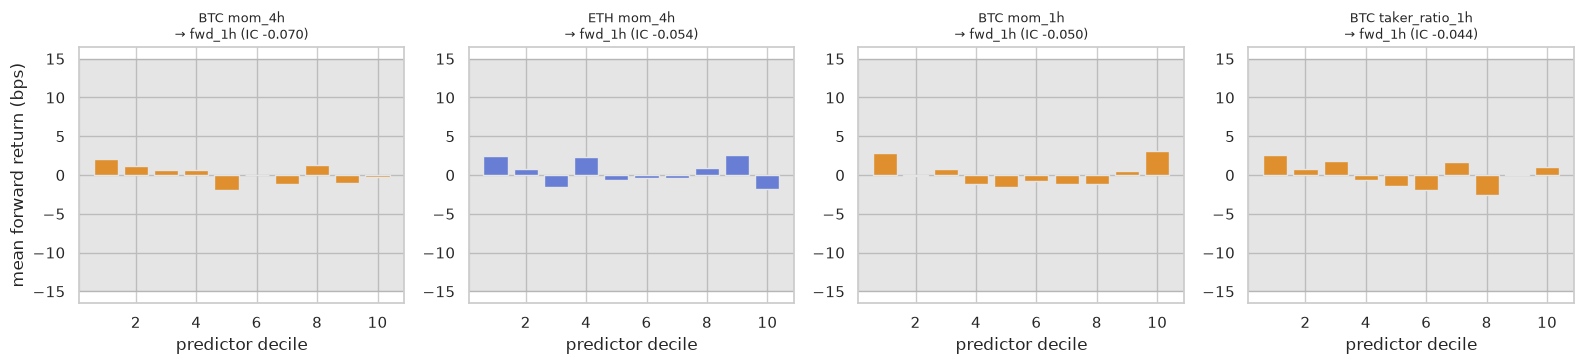

In [63]:
def decile_curve(x, y, h):
    d = pd.concat([x, y], axis=1).dropna().iloc[::h]
    d.columns = ["x", "y"]
    d["decile"] = pd.qcut(d["x"], 10, labels=False, duplicates="drop") + 1
    return d.groupby("decile")["y"].mean() * 1e4          # in bps


top = all_ic.sort_values("t", key=abs, ascending=False).head(4)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=False)
for ax, (_, row) in zip(axes, top.iterrows()):
    h = int(row["target"].split("_")[1][:-1])
    curve = decile_curve(X[row["asset"]][row["feature"]], Y[row["asset"]][row["target"]], h)
    ax.bar(curve.index, curve.values, color=COLORS[row["asset"]])
    ax.axhspan(-15, 15, color="grey", alpha=0.2)
    ax.set_title(f"{row['asset'][:3]} {row['feature']}\n→ {row['target']} (IC {row['IC']:.3f})", fontsize=9)
    ax.set_xlabel("predictor decile")
axes[0].set_ylabel("mean forward return (bps)")
fig.tight_layout()
savefig(fig, "decile_curves")

### 12.4 Statistically significant ≠ economically useful
For the strongest reversal signals: how many basis points separate the extreme deciles, compared with the 30 bps a round trip costs?

In [64]:
rows = {}
for s in ASSETS:
    for feature, target, h in [("mom_1h", "fwd_1h", 1), ("mom_4h", "fwd_1h", 1), ("mom_4h", "fwd_4h", 4), ("taker_ratio_1h", "fwd_1h", 1)]:
        curve = decile_curve(X[s][feature], Y[s][target], h)
        rows[(s, feature, target)] = {
            "lowest decile (bps)": curve.iloc[0],
            "highest decile (bps)": curve.iloc[-1],
            "spread D1 - D10 (bps)": curve.iloc[0] - curve.iloc[-1],
            "round-trip cost (bps)": 30,
        }
pd.DataFrame(rows).T

lowest decile (bps)  highest decile (bps)  spread D1 - D10 (bps)  round-trip cost (bps)
BTCUSDT mom_1h         fwd_1h               2.8204                3.0741                -0.2538                30.0000
        mom_4h         fwd_1h               2.0793               -0.2493                 2.3286                30.0000
                       fwd_4h              12.9892                0.0506                12.9386                30.0000
        taker_ratio_1h fwd_1h               2.5950                1.0692                 1.5259                30.0000
ETHUSDT mom_1h         fwd_1h               2.6030                5.6665                -3.0635                30.0000
        mom_4h         fwd_1h               2.4936               -1.8606                 4.3543                30.0000
                       fwd_4h               5.5013               -9.0659                14.5672                30.0000
        taker_ratio_1h fwd_1h              -1.3201                4.1465                -5.4666                30.0000

### 12.5 Do taker flow and the other asset add anything beyond the asset's own recent return?
They are correlated with the asset's own return, so they could just be proxies for it.
Partial IC: rank everything, remove the part explained by own 1 h and 4 h returns, and correlate what's left.

In [65]:
rows = {}
for s in ASSETS:
    f = pd.concat([X[s][["mom_1h", "mom_4h", "taker_ratio_1h", "other_ret_1h"]], Y[s]["fwd_1h"]], axis=1).dropna().rank()
    controls = sm.add_constant(f[["mom_1h", "mom_4h"]])
    y_resid = sm.OLS(f["fwd_1h"], controls).fit().resid
    for feature in ["taker_ratio_1h", "other_ret_1h"]:
        x_resid = sm.OLS(f[feature], controls).fit().resid
        ic = np.corrcoef(x_resid, y_resid)[0, 1]
        rows[(s, feature)] = {"partial IC (fwd_1h)": ic, "t": ic * np.sqrt(len(f))}
pd.DataFrame(rows).T

partial IC (fwd_1h)       t
BTCUSDT taker_ratio_1h              -0.0159 -2.5799
        other_ret_1h                 0.0038  0.6097
ETHUSDT taker_ratio_1h              -0.0013 -0.2037
        other_ret_1h                -0.0214 -3.4748

### 12.6 Classic time-series momentum on daily data
Go long if the past N-day return is positive, short if negative, and measure the next day's return (before costs).
A real effect should look similar for **neighbouring** lookbacks (e.g. 20, 30 and 45 days), not just one lucky N.

In [66]:
rows = {}
for s in ASSETS:
    r = rets["1d"][s]
    for n in [5, 10, 14, 20, 30, 45, 60, 90, 120]:
        signal_ret = (np.sign(r.rolling(n).sum()) * r.shift(-1)).dropna()
        by_year = signal_ret.groupby(signal_ret.index.year).mean() * 365 * 100
        rows[(s, n)] = {
            **{str(k): v for k, v in by_year.items()},
            "all (ann. %)": signal_ret.mean() * 365 * 100,
            "t-stat": signal_ret.mean() / signal_ret.std() * np.sqrt(len(signal_ret)),
        }
tsmom = pd.DataFrame(rows).T
tsmom.index.names = ["asset", "lookback (days)"]
tsmom

2021      2022     2023  all (ann. %)  t-stat
asset   lookback (days)                                                   
BTCUSDT 5                -17.6053 -103.2280  10.7800      -36.8156 -0.9857
        10                57.9316   -6.8524  -2.6728       15.7672  0.4224
        14                57.0054    0.6961  59.7755       38.9086  1.0460
        20                52.5987  -20.8775  69.5422       33.3702  0.8998
        30                77.4396   13.6938 103.2114       64.3886  1.7367
        45                -9.4672   19.5119  64.8917       26.4184  0.7166
        60                85.5383  -10.8604  52.9799       40.0482  1.0900
        90               -55.9012   25.5227   6.9653       -3.5077 -0.0941
        120             -146.7497   97.6414  43.1117       15.7886  0.4181
ETHUSDT 5                -30.3564  -36.9795   2.3736      -21.6362 -0.4462
        10               172.5101   -7.7031 -12.2702       49.7814  1.0280
        14                15.0034  125.9316 -31.2326       36.9098  0.7623
        20               -41.6002   23.4706 -38.4207      -18.4083 -0.3832
        30                97.8525   62.0962  17.2910       58.0259  1.2122
        45               -53.0871   24.1799  13.5129       -3.0920 -0.0643
        60                52.3846   31.0006  27.9314       36.2278  0.7524
        90               -41.2636    5.4733 -18.1905      -15.9074 -0.3250
        120                0.4541   86.9643   5.9955       34.9441  0.7054

### Findings: predictive information
- **A statistically real short-term reversal.** 33 of 78 tests have |t| > 2 (3.5 expected by chance) and 17 have |t| > 3 (0.2 expected), and nearly all keep the same sign in every year. The family is consistent: a big move over the last 1–24 h (own return, the other asset's return, heavy taker buying) is followed by a small move the other way over the next 1–4 h. Strongest: 4 h return → next 1 h, IC −0.07 (BTC, t = −11) and −0.05 (ETH, t = −9).
- **But it's economically tiny.** The gap between the extreme deciles is only a few bps over 1 h and ~13–15 bps over 4 h, against **30 bps per round trip**. As a standalone strategy it would lose money after costs. It *is* useful for **entry timing**: don't chase a 4-hour spike; wait for the pull-back.
- **The effect is non-linear:** for the last 1 h return, *both* extreme deciles are followed by slightly positive returns (a U shape). Most of the action is in the tails, which a linear model would miss.
- **Taker flow and the other asset are partly just proxies** for the asset's own return. After controlling for own 1 h/4 h returns, taker ratio keeps a small effect only for BTC (t ≈ −2.6), and BTC's return keeps a small effect only for ETH (t ≈ −3.5). Weak, and not symmetric between the assets. For ETH the taker-ratio deciles even point the *opposite* way to its IC (top decile +4 bps, bottom −1 bps), another sign the effect is fragile.
- **The strongest information is about size, not direction.** Last hour's range and the past 24 h volatility predict the size of the next 24 h move with IC 0.29–0.39, with the same sign every year. Volume surprise *also* ranks well overall but flips sign between years, so it's fragile.
- **Daily time-series momentum is not robust in 2021–23.** 30 days looks good (BTC +64% a year), but neighbouring lookbacks give very different, sometimes negative, results, and no lookback reaches |t| = 2. Choosing "30 days" because it worked here would be overfitting.

## 13. Summary

Full write-up: `reports/data_research_report.md`.

| # | Finding | Evidence | Robust? | Use |
|---|---|---|---|---|
| 1 | Data is clean; 3 outage bars are not flagged | Section 1–2 | Yes | Fix in preprocessing |
| 2 | BTC volume/trades have an exchange-made structural break | Zero-fee table | Yes | Only use relative volume features |
| 3 | Fat tails (α ≈ 3); biggest jumps arrive in calm markets | Hill, vol-scaled kurtosis | Yes | Hard exposure cap, conservative stop fills |
| 4 | Volatility is persistent and forecastable out of sample | HAR 2023 test | **Yes, strongest result** | Sizing, stops |
| 5 | Intraday volatility cycle (14–15 UTC high, 04–06 low) | Profiles across years | Yes | Hour-aware risk/execution |
| 6 | No hour/weekday *return* effect | Profile corr < 0 | Yes (as a null) | Don't trade calendar returns |
| 7 | Direction ≈ unpredictable at scale; character flips by year | VR per year | Yes (as a null) | Expect regime dependence |
| 8 | Short-term reversal (1–4 h) is real but smaller than costs | IC t ≈ −11, deciles | Stat. yes / econ. no | Entry timing only |
| 9 | BTC–ETH: one common factor; crash together, rally apart | Tail co-exceedance | Yes | Joint risk limits |
| 10 | ETH/BTC mean reversion | Per-year ADF | **No, fragile** | Don't pairs trade |
| 11 | Daily momentum | Lookback grid | **No, fragile** | Test carefully |
| 12 | Trend filter predicts risk, not return | 200d MA split | Moderate | Risk switch |